# **This notebook is intended solely for exploratory analysis of the NVIDIA PhysicalAI dataset.**
# **It is not part of the final multimodal data pipeline and is therefore excluded from formal review and evaluation.**

---

# **From Metadata to Visual Evidence: Identifying Rare Driving Scenarios in Autonomous Vehicle Data**

**Student:** Prasanna Syam Shreyas Nair 20075899@mydbs.ie   
**Module:** Applied Research Project / Dissertation  
**Supervisor:** Obinna Izima obinna.izima@dbs.ie

<br>

---

*Everything done till now is as a proof of concept. Further enhancement and exploration will be done as we move forward in this research.*

---

<br>

## **Overview**
* End-to-end pipeline for identifying rare driving scenarios in autonomous driving domain  
* Uses metadata-driven anomaly detection  
* Validated using statistical analysis and visual evidence  

## **Dataset**
**NVIDIA Physical AI Autonomous Vehicles Dataset**   
https://huggingface.co/datasets/nvidia/PhysicalAI-Autonomous-Vehicles  

* A very recent large-scale multimodal dataset in the autonomous driving domain  
* The dataset contains ~300,000+ driving clips, each representing a short real-world driving scenario identified by a unique clip_id (Dataset size 133 TB)  
* Data is primarily accessed through structured metadata (Parquet format), containing attributes such as location, time, platform type, and sensor configuration  
* Sensor data is stored separately in a chunk-based system, where each chunk contains multiple clips (~100 per chunk) for efficient storage and scalability  
* The mapping between clip_id and its corresponding chunk is maintained in clip_index.parquet, enabling selective retrieval of required video data  
* The dataset is multimodal, including camera videos, LiDAR, radar, ego-motion, and calibration data, and is designed for large-scale analysis without requiring full dataset download  
* Designed for scalable analysis of complex and rare driving scenarios that are difficult to capture using traditional datasets  

## **Replicability**  
* Framework is dataset-agnostic and transferable
* Can be applied to datasets like nuScenes, Waymo, and KITTI
* Requires structured metadata + linked sensor data
* Supports scalable rare scenario detection across datasets

## **Research Gap**
* Existing methods rely heavily on raw sensor data and manual annotation  
* Limited use of metadata for rare scenario detection  
* Lack of scalable approaches for large datasets  

## **Contribution**
* Proposed a metadata-driven anomaly detection framework
* Used unsupervised learning (K-Means + Isolation Forest)
* Validated results using visual metrics (brightness, contrast)  
* Applied YOLO as a weak validation signal
* Demonstrated that metadata can identify rare, perception-challenging scenarios  
* Provided a computationally efficient and generalisable approach

In [ ]:
# ============================================================
# STEP 1: INSTALL THE REQUIRED LIBRARIES
# ============================================================
# This cell installs the Python packages that we will need
# for this dissertation project.
#
# Why we need them:
# - datasets         -> to interact with datasets hosted on Hugging Face
# - huggingface_hub  -> to log in and download files from Hugging Face
# - pyarrow          -> to open Parquet files (the metadata format)
# - pandas           -> to view and work with tables like Excel
#
# "-q" means quiet mode, so Colab shows less unnecessary text.

!pip -q install -U datasets huggingface_hub pyarrow pandas

# This print statement is only to confirm the step is complete.
print("Step 1 complete: Required libraries installed successfully.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
Step 1 complete: Required libraries installed successfully.


In [ ]:
# ============================================================
# STEP 2: FIX PANDAS VERSION FOR GOOGLE COLAB
# ============================================================
# In Step 1, pip upgraded pandas to version 3.0.1.
# However, Google Colab currently works best with pandas 2.2.2.
#
# If we do not fix this, some libraries in Colab may behave
# unpredictably later when we analyse the dataset.
#
# Therefore we explicitly reinstall pandas version 2.2.2.

!pip install pandas==2.2.2

# After installation, we import pandas and print its version
# to confirm the correct version is active.

import pandas as pd

print("Current pandas version:", pd.__version__)
print("Step 2 complete: Pandas version fixed for Colab compatibility.")

  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.7 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.2
    Uninstalling pandas-3.0.2:
      Successfully uninstalled pandas-3.0.2
Current pandas version: 2.2.2
Step 2 complete: Pandas version fixed for Colab compatibility.


In [ ]:
# ============================================================
# STEP 3: LOGIN TO HUGGING FACE
# ============================================================
# Hugging Face requires authentication before allowing
# access to some datasets (including the NVIDIA PhysicalAI dataset).
#
# When this cell runs, a login box will appear.
#
# You will need a Hugging Face access token.
#
# To create a token:
# 1. Go to: https://huggingface.co/settings/tokens
# 2. Click "New Token"
# 3. Name it something like: colab_access
# 4. Set permission to: READ
# 5. Copy the generated token

from huggingface_hub import login

# This command will open a small authentication box
login()

print("Login successful. Your Colab notebook is now connected to Hugging Face.")

Login successful. Your Colab notebook is now connected to Hugging Face.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# ============================================================
# STEP 4: VERIFY ACCESS TO THE NVIDIA DATASET
# ============================================================
# In this step we will NOT download any data yet.
#
# Instead, we will simply check if our Colab notebook
# can see the dataset files stored on Hugging Face.
#
# This is important because:
# - the dataset is gated (requires license acceptance)
# - we need to confirm our login works correctly
#
# If this works, it means we can safely download metadata later.

from huggingface_hub import list_repo_files

# Name of the dataset repository on Hugging Face
dataset_name = "nvidia/PhysicalAI-Autonomous-Vehicles"

# List files inside the dataset repository
files = list_repo_files(dataset_name, repo_type="dataset")

# Print the first 30 files so we can inspect the structure
print("Number of files found in repository:", len(files))
print("\nFirst 30 files in the dataset:\n")

for file in files[:30]:
    print(file)

print("\nStep 4 complete: Dataset repository is accessible.")

Number of files found in repository: 70775

First 30 files in the dataset:

.gitattributes
LICENSE.pdf
README.md
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0000.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0001.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0002.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0003.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0004.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0005.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0006.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0007.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0008.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.offline.chunk_0009.parquet
calibration/camera_intrinsics.offline/camera_intrinsics.o

In [ ]:
# ============================================================
# STEP 5: SEARCH THE DATASET REPOSITORY FOR METADATA FILES
# ============================================================
# We already confirmed that the NVIDIA dataset repository is accessible.
# Now we want to locate the SMALL metadata files that will be useful
# for our dissertation.
#
# Why this is important:
# - The full dataset is extremely large
# - We do NOT want to download videos or sensor data yet
# - We first want the metadata files, because they behave more like
#   an Excel-style table and are easier to inspect and analyse
#
# In this step, we will search through the repository file list
# and print file paths that contain important keywords such as:
# - metadata
# - sensor
# - collection
# - clip
# - presence
#
# This will help us identify the exact file paths we should download next.

# Keywords that may help us find useful metadata files
keywords = ["metadata", "sensor", "collection", "clip", "presence"]

print("Searching for likely metadata-related files...\n")

# Loop through every file path in the repository
for file in files:
    file_lower = file.lower()  # convert to lowercase so search is easier

    # Check whether any of our keywords appear in the file path
    if any(keyword in file_lower for keyword in keywords):
        print(file)

print("\nStep 5 complete: Metadata-related file paths have been listed above.")

Searching for likely metadata-related files...

calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0000.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0001.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0002.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0003.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0004.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0005.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0006.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0007.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0008.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0009.parquet
calibration/sensor_extrinsics.offline/sensor_extrinsics.offline.chunk_0010.parquet
calibration/sensor_extrinsics.offline/s

In [ ]:
# ============================================================
# STEP 6: DOWNLOAD THE TWO MAIN METADATA FILES
# ============================================================
# We have identified the two most important metadata files
# for Phase 1 of the dissertation:
#
# 1. metadata/data_collection.parquet
#    -> contains where/when/platform information
#
# 2. metadata/sensor_presence.parquet
#    -> contains which sensors are available for each clip
#
# These files are small compared to the full dataset and are
# the correct starting point for understanding the dataset structure.

from huggingface_hub import hf_hub_download
import os

# Name of the dataset repository
dataset_name = "nvidia/PhysicalAI-Autonomous-Vehicles"

# Download the data_collection metadata file
data_collection_file = hf_hub_download(
    repo_id=dataset_name,
    filename="metadata/data_collection.parquet",
    repo_type="dataset"
)

# Download the sensor_presence metadata file
feature_presence_file = hf_hub_download(
    repo_id=dataset_name,
    filename="metadata/feature_presence.parquet",
    repo_type="dataset"
)

# Print the local file paths so we know where Colab saved them
print("Downloaded files successfully.\n")

print("Data Collection file saved at:")
print(data_collection_file)

print("\nFeature Presence file saved at:")
print(feature_presence_file)

# Confirm that the files really exist
print("\nFile existence check:")
print("data_collection.parquet exists:", os.path.exists(data_collection_file))
print("feature_presence.parquet exists:", os.path.exists(feature_presence_file))

print("\nStep 6 complete: Both metadata files have been downloaded.")

Downloaded files successfully.

Data Collection file saved at:
/root/.cache/huggingface/hub/datasets--nvidia--PhysicalAI-Autonomous-Vehicles/snapshots/dfcc35f941c38f050e9ce256a4c0aff9e33615b9/metadata/data_collection.parquet

Feature Presence file saved at:
/root/.cache/huggingface/hub/datasets--nvidia--PhysicalAI-Autonomous-Vehicles/snapshots/dfcc35f941c38f050e9ce256a4c0aff9e33615b9/metadata/feature_presence.parquet

File existence check:
data_collection.parquet exists: True
feature_presence.parquet exists: True

Step 6 complete: Both metadata files have been downloaded.


In [ ]:
# ============================================================
# STEP 7: READ THE METADATA FILES INTO TABLES
# ============================================================
# In the previous step, we downloaded two important metadata files:
#
# 1. data_collection.parquet
# 2. feature_presence.parquet
#
# These files are stored in Parquet format, which is a compact
# data storage format commonly used in data science.
#
# In this step, we will:
# - open both files using pandas
# - store them as tables (DataFrames)
# - inspect their size (rows and columns)
# - inspect their column names
# - preview the first 5 rows
#
# A pandas DataFrame is similar to an Excel sheet:
# - rows = observations
# - columns = variables/features

import pandas as pd

# ------------------------------------------------------------
# READ THE TWO PARQUET FILES INTO PANDAS DATAFRAMES
# ------------------------------------------------------------
# We use pd.read_parquet() because the metadata files are stored
# in Parquet format, not CSV or Excel format.

data_collection_df = pd.read_parquet(data_collection_file)
feature_presence_df = pd.read_parquet(feature_presence_file)

# ------------------------------------------------------------
# PRINT BASIC INFORMATION ABOUT EACH TABLE
# ------------------------------------------------------------
# .shape gives us:
# - number of rows
# - number of columns

print("============================================================")
print("DATA COLLECTION TABLE")
print("============================================================")
print("Shape (rows, columns):", data_collection_df.shape)

print("\nColumn names:")
print(list(data_collection_df.columns))

print("\nFirst 5 rows:")
display(data_collection_df.head())

print("\n\n============================================================")
print("FEATURE PRESENCE TABLE")
print("============================================================")
print("Shape (rows, columns):", feature_presence_df.shape)

print("\nColumn names:")
print(list(feature_presence_df.columns))

print("\nFirst 5 rows:")
display(feature_presence_df.head())

print("\nStep 7 complete: Both metadata tables have been loaded and previewed.")

DATA COLLECTION TABLE
Shape (rows, columns): (306152, 5)

Column names:
['country', 'month', 'hour_of_day', 'platform_class', 'radar_config']

First 5 rows:




FEATURE PRESENCE TABLE
Shape (rows, columns): (306152, 36)

Column names:
['egomotion', 'egomotion.offline', 'obstacle.offline', 'camera_intrinsics', 'camera_intrinsics.offline', 'lidar_intrinsics.offline', 'sensor_extrinsics', 'sensor_extrinsics.offline', 'vehicle_dimensions', 'camera_cross_left_120fov', 'camera_cross_right_120fov', 'camera_front_tele_30fov', 'camera_front_wide_120fov', 'camera_rear_left_70fov', 'camera_rear_right_70fov', 'camera_rear_tele_30fov', 'lidar_top_360fov', 'radar_corner_front_left_srr_0', 'radar_corner_front_left_srr_3', 'radar_corner_front_right_srr_0', 'radar_corner_front_right_srr_3', 'radar_corner_rear_left_srr_0', 'radar_corner_rear_left_srr_3', 'radar_corner_rear_right_srr_0', 'radar_corner_rear_right_srr_3', 'radar_front_center_imaging_lrr_1', 'radar_front_center_mrr_2', 'radar_front_center_srr_0', 'radar_rear_left_mrr_2', 'radar_rear_left_srr_0', 'radar_rear_right_mrr_2', 'radar_rear_right_srr_0', 'radar_side_left_srr_0', 'radar_side_left_srr_3', 


Step 7 complete: Both metadata tables have been loaded and previewed.


In [ ]:
# ============================================================
# STEP 8: MERGE THE TWO METADATA TABLES INTO ONE MASTER TABLE
# ============================================================
# We currently have two separate tables:
#
# 1. data_collection_df
#    -> contains contextual metadata such as:
#       country, month, hour_of_day, platform_class
#
# 2. feature_presence_df
#    -> contains sensor availability information such as:
#       camera presence, lidar presence, radar presence, radar_config
#
# Both tables use clip_id as their index.
# That means each row in both tables refers to the same driving clip.
#
# In this step, we will combine both tables into one larger table.
# This is called a "merge" or "join".
#
# Because both tables represent the same set of clips,
# we use an INNER JOIN on the index.
# This means:
# - keep only rows that appear in both tables
# - match them using clip_id
#
# The final result will be our main metadata dataset
# for Phase 1 rarity analysis.

# ------------------------------------------------------------
# MERGE THE TABLES USING THEIR INDEX (clip_id)
# ------------------------------------------------------------
master_df = data_collection_df.join(feature_presence_df, how="inner")

# ------------------------------------------------------------
# PRINT BASIC INFORMATION ABOUT THE MERGED TABLE
# ------------------------------------------------------------
print("============================================================")
print("MASTER METADATA TABLE")
print("============================================================")

# Show the size of the merged table
print("Shape (rows, columns):", master_df.shape)

# Show the column names
print("\nColumn names:")
print(list(master_df.columns))

# Preview the first 5 rows
print("\nFirst 5 rows:")
display(master_df.head())

print("\nStep 8 complete: The two metadata tables have been merged successfully.")

MASTER METADATA TABLE
Shape (rows, columns): (306152, 41)

Column names:
['country', 'month', 'hour_of_day', 'platform_class', 'radar_config', 'egomotion', 'egomotion.offline', 'obstacle.offline', 'camera_intrinsics', 'camera_intrinsics.offline', 'lidar_intrinsics.offline', 'sensor_extrinsics', 'sensor_extrinsics.offline', 'vehicle_dimensions', 'camera_cross_left_120fov', 'camera_cross_right_120fov', 'camera_front_tele_30fov', 'camera_front_wide_120fov', 'camera_rear_left_70fov', 'camera_rear_right_70fov', 'camera_rear_tele_30fov', 'lidar_top_360fov', 'radar_corner_front_left_srr_0', 'radar_corner_front_left_srr_3', 'radar_corner_front_right_srr_0', 'radar_corner_front_right_srr_3', 'radar_corner_rear_left_srr_0', 'radar_corner_rear_left_srr_3', 'radar_corner_rear_right_srr_0', 'radar_corner_rear_right_srr_3', 'radar_front_center_imaging_lrr_1', 'radar_front_center_mrr_2', 'radar_front_center_srr_0', 'radar_rear_left_mrr_2', 'radar_rear_left_srr_0', 'radar_rear_right_mrr_2', 'radar_rea


Step 8 complete: The two metadata tables have been merged successfully.


In [ ]:
# ============================================================
# STEP 9: SAVE THE MASTER DATASET TO FILES
# ============================================================
# We will save two versions of the dataset:
#
# 1) Full dataset as CSV
#    -> contains all 306k clips
#
# 2) Smaller Excel sample
#    -> easier to open and inspect

# Save full dataset
master_df.to_csv("nvidia_metadata_master_dataset.csv")

print("Full dataset saved as CSV.")

# Save sample for Excel viewing
sample_df = master_df.head(10000)

sample_df.to_excel("nvidia_metadata_sample.xlsx")

print("Excel sample (10k rows) saved.")

print("\nStep 9 complete.")

Full dataset saved as CSV.
Excel sample (10k rows) saved.

Step 9 complete.


MISSING VALUES CHECK
radar_config    145391
dtype: int64

TOP COUNTRIES
country
United States    155360
Germany           43900
France            10364
Italy              8658
Sweden             7330
Spain              6459
Portugal           6101
Greece             5885
Austria            5451
Finland            5176
Name: count, dtype: int64


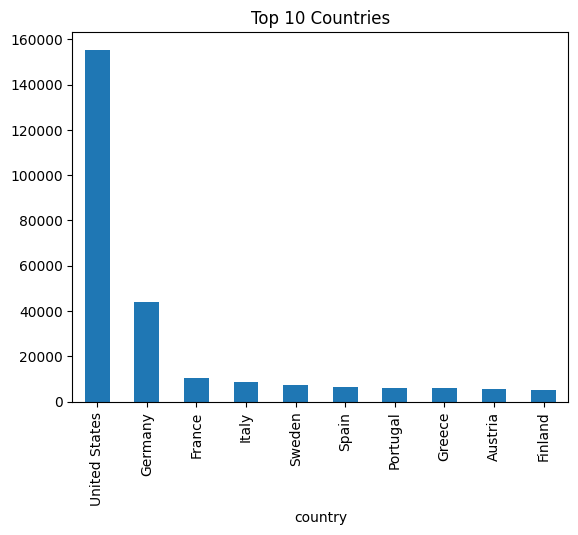


HOUR OF DAY DISTRIBUTION


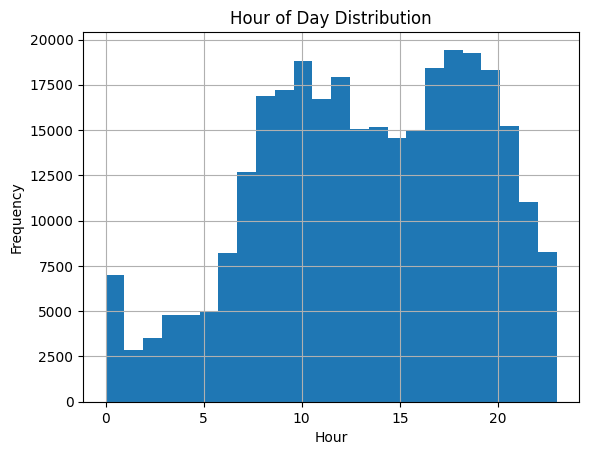


PLATFORM DISTRIBUTION
platform_class
hyperion_8.1    218588
hyperion_8       87564
Name: count, dtype: int64


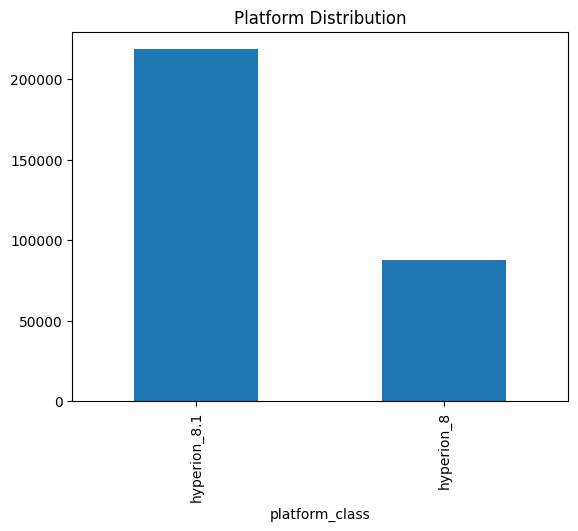


Step 10 complete: Basic dataset understanding done.


In [ ]:
# ============================================================
# STEP 10: BASIC DATA EXPLORATION (EDA)
# ============================================================
# Before applying machine learning, we must understand the data.
#
# This step helps us:
# - check if any values are missing
# - understand distributions
# - identify patterns in the dataset
#
# This is VERY important for your supervisor meeting,
# because it shows you have already started analysing the data.

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CHECK FOR MISSING VALUES
# ------------------------------------------------------------
print("============================================================")
print("MISSING VALUES CHECK")
print("============================================================")

missing_values = master_df.isnull().sum()
print(missing_values[missing_values > 0])

# ------------------------------------------------------------
# DISTRIBUTION: COUNTRY
# ------------------------------------------------------------
print("\n============================================================")
print("TOP COUNTRIES")
print("============================================================")

country_counts = master_df['country'].value_counts().head(10)
print(country_counts)

country_counts.plot(kind='bar', title='Top 10 Countries')
plt.show()

# ------------------------------------------------------------
# DISTRIBUTION: HOUR OF DAY
# ------------------------------------------------------------
print("\n============================================================")
print("HOUR OF DAY DISTRIBUTION")
print("============================================================")

master_df['hour_of_day'].hist(bins=24)
plt.title("Hour of Day Distribution")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------------------
# DISTRIBUTION: PLATFORM CLASS
# ------------------------------------------------------------
print("\n============================================================")
print("PLATFORM DISTRIBUTION")
print("============================================================")

platform_counts = master_df['platform_class'].value_counts()
print(platform_counts)

platform_counts.plot(kind='bar', title='Platform Distribution')
plt.show()

print("\nStep 10 complete: Basic dataset understanding done.")

In [ ]:
# ============================================================
# STEP 11: FEATURE ENGINEERING FOR MACHINE LEARNING
# ============================================================
# In this step, we prepare the dataset for ML models.
#
# ML models cannot understand:
# - text (like "USA", "Germany")
# - True/False values
#
# So we convert everything into numbers.

import numpy as np

# ------------------------------------------------------------
# STEP 11.1: RESET INDEX (bring clip_id as column)
# ------------------------------------------------------------
master_df = master_df.reset_index()

# ------------------------------------------------------------
# STEP 11.2: HANDLE MISSING VALUES
# ------------------------------------------------------------
# Fill missing radar_config with "unknown"
master_df["radar_config"] = master_df["radar_config"].fillna("unknown")

# ------------------------------------------------------------
# STEP 11.3: CONVERT BOOLEAN → INTEGER
# ------------------------------------------------------------
# True → 1, False → 0

bool_columns = master_df.select_dtypes(include=["bool"]).columns

for col in bool_columns:
    master_df[col] = master_df[col].astype(int)

# ------------------------------------------------------------
# STEP 11.4: ENCODE CATEGORICAL VARIABLES
# ------------------------------------------------------------
# Convert text columns into numeric using Label Encoding

from sklearn.preprocessing import LabelEncoder

categorical_cols = ["country", "platform_class", "radar_config"]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    master_df[col] = le.fit_transform(master_df[col])
    label_encoders[col] = le

# ------------------------------------------------------------
# STEP 11.5: DROP clip_id (not useful for ML)
# ------------------------------------------------------------
ml_df = master_df.drop(columns=["clip_id"])

# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------
print("============================================================")
print("ML DATASET READY")
print("============================================================")
print("Shape:", ml_df.shape)

print("\nSample rows:")
display(ml_df.head())

print("\nStep 11 complete: Dataset is now ready for ML models.")

ML DATASET READY
Shape: (306152, 41)

Sample rows:



Step 11 complete: Dataset is now ready for ML models.


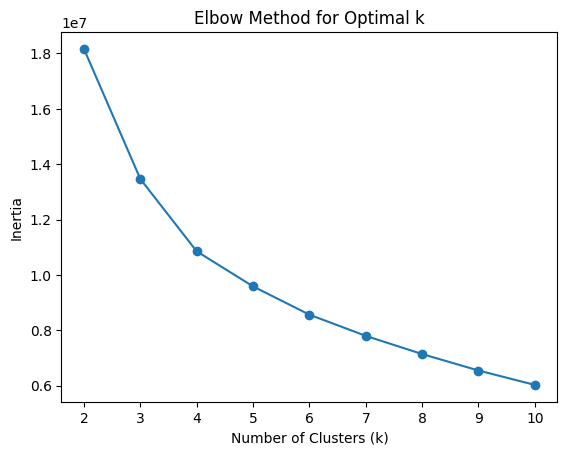

Step 12 complete: Elbow graph generated.


In [ ]:
# ============================================================
# STEP 12: FIND OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)
# ============================================================
# We test multiple cluster values (k) and measure how well
# the data fits into clusters.
#
# The goal:
# - find a point where improvement slows down
# - this is the "elbow"

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store inertia (error) for each k
inertia = []

# Test k from 2 to 10
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(ml_df)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

print("Step 12 complete: Elbow graph generated.")

CLUSTER DISTRIBUTION
cluster
0    99859
1    48877
2    62871
3    94545
Name: count, dtype: int64


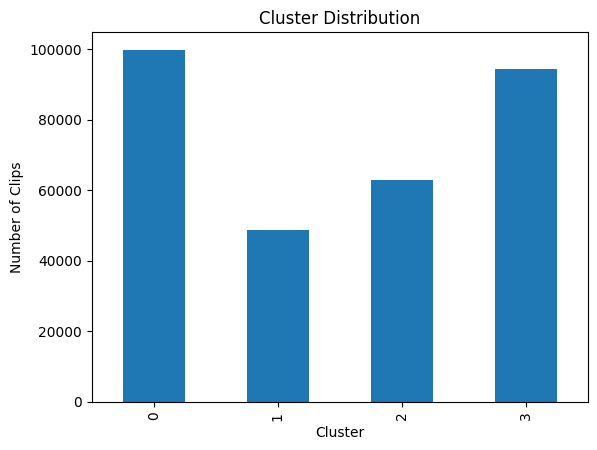


Step 13 complete: Clusters assigned.


In [ ]:
# ============================================================
# STEP 13: APPLY K-MEANS CLUSTERING
# ============================================================
# Now we use k = 4 (from elbow method) to cluster the data.
#
# This will assign each clip into one of 4 groups.

from sklearn.cluster import KMeans

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit model and assign cluster labels
ml_df["cluster"] = kmeans.fit_predict(ml_df)

# ------------------------------------------------------------
# ANALYSE CLUSTER DISTRIBUTION
# ------------------------------------------------------------
print("============================================================")
print("CLUSTER DISTRIBUTION")
print("============================================================")

cluster_counts = ml_df["cluster"].value_counts().sort_index()
print(cluster_counts)

# Plot cluster sizes
cluster_counts.plot(kind="bar", title="Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Clips")
plt.show()

print("\nStep 13 complete: Clusters assigned.")

In [ ]:
# ============================================================
# STEP 14: APPLY ISOLATION FOREST (RARITY DETECTION)
# ============================================================
# Isolation Forest is used to detect anomalies (rare cases).
#
# It works by:
# - randomly splitting data
# - rare points get isolated faster
#
# Output:
# - anomaly_score
# - label (rare or normal)

from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# CREATE MODEL
# ------------------------------------------------------------
# contamination = expected % of rare cases
# We assume ~5% rare scenarios

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

# ------------------------------------------------------------
# FIT MODEL
# ------------------------------------------------------------
iso_forest.fit(ml_df.drop(columns=["cluster"]))

# ------------------------------------------------------------
# GENERATE SCORES
# ------------------------------------------------------------
ml_df["anomaly_score"] = iso_forest.decision_function(
    ml_df.drop(columns=["cluster"])
)

ml_df["anomaly_label"] = iso_forest.predict(
    ml_df.drop(columns=["cluster"])
)

# ------------------------------------------------------------
# CHECK RESULTS
# ------------------------------------------------------------
print("============================================================")
print("ANOMALY LABEL DISTRIBUTION")
print("============================================================")

print(ml_df["anomaly_label"].value_counts())

# -1 = anomaly (rare)
#  1 = normal

print("\nStep 14 complete: Rarity scores generated.")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- anomaly_score


In [ ]:
# ============================================================
# STEP 14 (CORRECTED): APPLY ISOLATION FOREST FOR RARITY
# ============================================================
# In the previous attempt, an error happened because a new column
# ("anomaly_score") was added to ml_df before prediction.
#
# Machine learning models require the prediction data to have
# exactly the same columns as the training data.
#
# To fix this properly, we create a separate feature table
# that contains only the original modelling columns.

from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# CREATE A CLEAN FEATURE MATRIX
# ------------------------------------------------------------
# We exclude only the cluster label because it was created by K-Means
# and is not part of the original metadata features for anomaly detection.
X_iso = ml_df.drop(columns=["cluster"]).copy()

# ------------------------------------------------------------
# CREATE THE ISOLATION FOREST MODEL
# ------------------------------------------------------------
# contamination = expected proportion of anomalies
# We start with 5%, which is a reasonable assumption for rare cases.

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

# ------------------------------------------------------------
# FIT THE MODEL
# ------------------------------------------------------------
iso_forest.fit(X_iso)

# ------------------------------------------------------------
# GENERATE ANOMALY SCORES
# ------------------------------------------------------------
# decision_function():
# - higher score = more normal
# - lower score = more unusual

anomaly_scores = iso_forest.decision_function(X_iso)

# predict():
# -  1  = normal
# - -1  = anomaly / rare

anomaly_labels = iso_forest.predict(X_iso)

# ------------------------------------------------------------
# SAVE RESULTS BACK INTO ml_df
# ------------------------------------------------------------
ml_df["anomaly_score"] = anomaly_scores
ml_df["anomaly_label"] = anomaly_labels

# ------------------------------------------------------------
# CHECK THE RESULT DISTRIBUTION
# ------------------------------------------------------------
print("============================================================")
print("ANOMALY LABEL DISTRIBUTION")
print("============================================================")
print(ml_df["anomaly_label"].value_counts())

print("\nLowest anomaly scores (most unusual clips):")
display(ml_df[["anomaly_score", "anomaly_label"]].sort_values("anomaly_score").head(10))

print("\nStep 14 complete: Isolation Forest rarity detection successful.")

ANOMALY LABEL DISTRIBUTION
anomaly_label
 1    290864
-1     15288
Name: count, dtype: int64

Lowest anomaly scores (most unusual clips):



Step 14 complete: Isolation Forest rarity detection successful.


In [ ]:
# ============================================================
# STEP 15: EXTRACT RARE SCENARIOS
# ============================================================
# Now we isolate only the rare clips (-1)
# This becomes our "rare scenarios dataset"

# Extract rare clips
rare_df = master_df.loc[ml_df["anomaly_label"] == -1].copy()

# Add anomaly score for reference
rare_df["anomaly_score"] = ml_df.loc[ml_df["anomaly_label"] == -1, "anomaly_score"]

# ------------------------------------------------------------
# SORT BY MOST RARE
# ------------------------------------------------------------
rare_df = rare_df.sort_values(by="anomaly_score")

# ------------------------------------------------------------
# CHECK OUTPUT
# ------------------------------------------------------------
print("============================================================")
print("RARE SCENARIOS DATASET")
print("============================================================")
print("Shape:", rare_df.shape)

print("\nTop 10 most rare clips:")
display(rare_df.head(10))

# ------------------------------------------------------------
# SAVE FILE
# ------------------------------------------------------------
rare_df.to_csv("rare_scenarios_dataset.csv", index=False)

print("\nStep 15 complete: Rare scenarios dataset created and saved.")

RARE SCENARIOS DATASET
Shape: (15288, 43)

Top 10 most rare clips:



Step 15 complete: Rare scenarios dataset created and saved.


RARE SCENARIOS BY COUNTRY

Top countries in rare scenarios:
country
24    6406
9     2108
7     1239
1     1083
0     1007
5      510
22     367
12     269
6      239
8      220
Name: count, dtype: int64


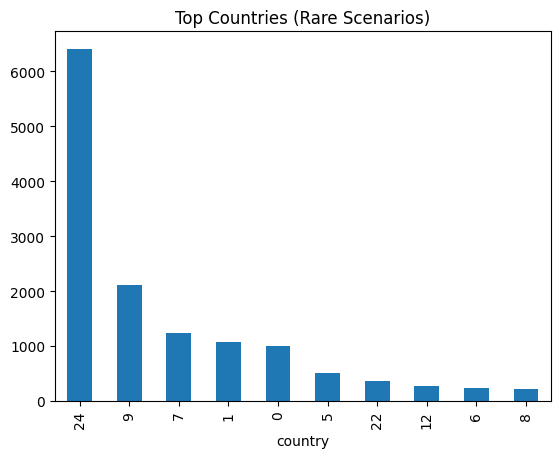


RARE SCENARIOS BY HOUR


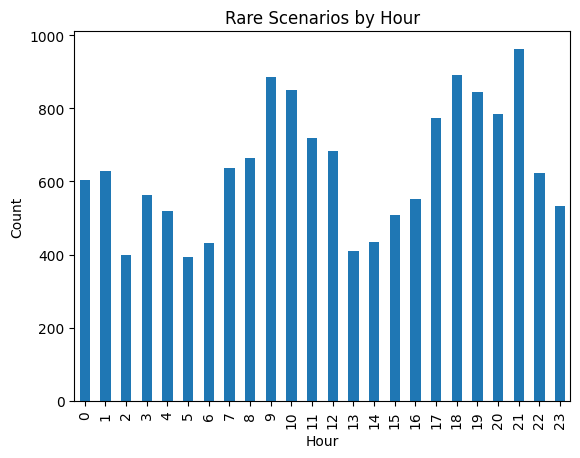


RARE SCENARIOS BY PLATFORM
platform_class
1    11200
0     4088
Name: count, dtype: int64


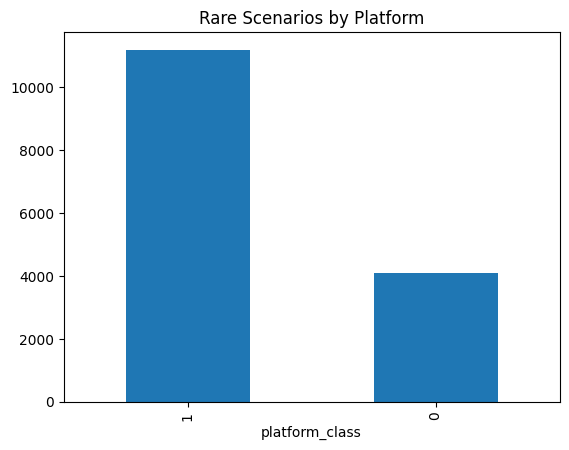


RARE SCENARIOS BY RADAR CONFIG
radar_config
0    5787
1    4083
3    3922
2    1496
Name: count, dtype: int64


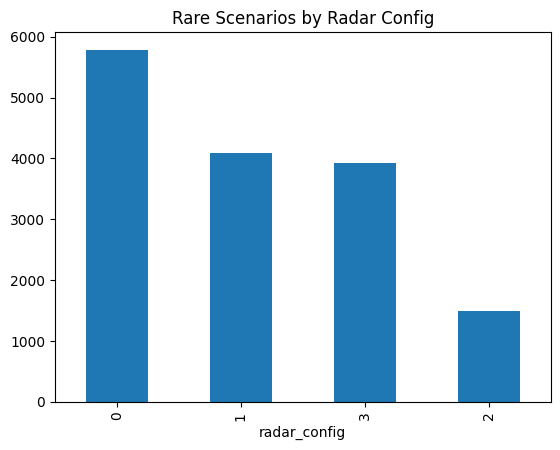


Step 16 complete: Insights generated.


In [ ]:
# ============================================================
# STEP 16: GENERATE INSIGHTS FROM RARE SCENARIOS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# INSIGHT 1: COUNTRY DISTRIBUTION (RARE vs FULL)
# ------------------------------------------------------------
print("============================================================")
print("RARE SCENARIOS BY COUNTRY")
print("============================================================")

rare_country = rare_df["country"].value_counts().head(10)
full_country = master_df["country"].value_counts().head(10)

print("\nTop countries in rare scenarios:")
print(rare_country)

# Plot comparison
rare_country.plot(kind="bar", title="Top Countries (Rare Scenarios)")
plt.show()


# ------------------------------------------------------------
# INSIGHT 2: HOUR OF DAY (RARE vs FULL)
# ------------------------------------------------------------
print("\n============================================================")
print("RARE SCENARIOS BY HOUR")
print("============================================================")

rare_hours = rare_df["hour_of_day"].value_counts().sort_index()

rare_hours.plot(kind="bar", title="Rare Scenarios by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


# ------------------------------------------------------------
# INSIGHT 3: PLATFORM CLASS
# ------------------------------------------------------------
print("\n============================================================")
print("RARE SCENARIOS BY PLATFORM")
print("============================================================")

rare_platform = rare_df["platform_class"].value_counts()
print(rare_platform)

rare_platform.plot(kind="bar", title="Rare Scenarios by Platform")
plt.show()


# ------------------------------------------------------------
# INSIGHT 4: RADAR CONFIGURATION
# ------------------------------------------------------------
print("\n============================================================")
print("RARE SCENARIOS BY RADAR CONFIG")
print("============================================================")

rare_radar = rare_df["radar_config"].value_counts()
print(rare_radar)

rare_radar.plot(kind="bar", title="Rare Scenarios by Radar Config")
plt.show()

print("\nStep 16 complete: Insights generated.")

In [ ]:
# ============================================================
# STEP 17: DECODE LABELS FOR INTERPRETABLE INSIGHTS
# ============================================================

# We stored label encoders earlier in Step 11

# Decode country
rare_df["country_decoded"] = label_encoders["country"].inverse_transform(rare_df["country"])

# Decode platform
rare_df["platform_decoded"] = label_encoders["platform_class"].inverse_transform(rare_df["platform_class"])

# Decode radar config
rare_df["radar_decoded"] = label_encoders["radar_config"].inverse_transform(rare_df["radar_config"])

# ------------------------------------------------------------
# RE-CALCULATE INSIGHTS WITH REAL LABELS
# ------------------------------------------------------------
print("============================================================")
print("RARE SCENARIOS BY COUNTRY (DECODED)")
print("============================================================")

print(rare_df["country_decoded"].value_counts().head(10))


print("\n============================================================")
print("RARE SCENARIOS BY PLATFORM (DECODED)")
print("============================================================")

print(rare_df["platform_decoded"].value_counts())


print("\n============================================================")
print("RARE SCENARIOS BY RADAR CONFIG (DECODED)")
print("============================================================")

print(rare_df["radar_decoded"].value_counts())

print("\nStep 17 complete: Insights are now human-readable.")

RARE SCENARIOS BY COUNTRY (DECODED)
country_decoded
United States    6406
Germany          2108
Finland          1239
Belgium          1083
Austria          1007
Denmark           510
Spain             367
Italy             269
Estonia           239
France            220
Name: count, dtype: int64

RARE SCENARIOS BY PLATFORM (DECODED)
platform_decoded
hyperion_8.1    11200
hyperion_8       4088
Name: count, dtype: int64

RARE SCENARIOS BY RADAR CONFIG (DECODED)
radar_decoded
high       5787
low        4083
unknown    3922
med        1496
Name: count, dtype: int64

Step 17 complete: Insights are now human-readable.


In [ ]:
# ============================================================
# STEP 18: CREATE RARE vs NORMAL COMPARISON DATASETS
# ============================================================

# ------------------------------------------------------------
# RARE CLIPS (already identified)
# ------------------------------------------------------------
rare_sample = rare_df.sample(n=100, random_state=42)

# ------------------------------------------------------------
# NORMAL CLIPS (random sample from normal data)
# ------------------------------------------------------------
normal_df = master_df.loc[ml_df["anomaly_label"] == 1]

normal_sample = normal_df.sample(n=100, random_state=42)

# ------------------------------------------------------------
# CHECK OUTPUT
# ------------------------------------------------------------
print("============================================================")
print("SAMPLE DATASETS CREATED")
print("============================================================")

print("Rare sample size:", rare_sample.shape)
print("Normal sample size:", normal_sample.shape)

print("\nStep 18 complete.")

SAMPLE DATASETS CREATED
Rare sample size: (100, 46)
Normal sample size: (100, 42)

Step 18 complete.


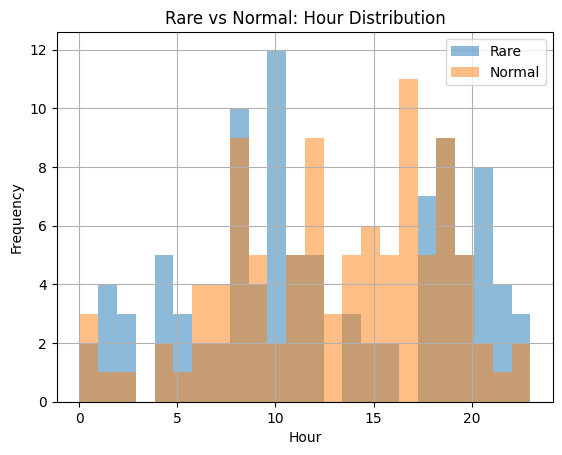

PLATFORM COMPARISON
Rare:
platform_class
1    71
0    29
Name: count, dtype: int64

Normal:
platform_class
1    69
0    31
Name: count, dtype: int64

Step 19 complete.


In [ ]:
# ============================================================
# STEP 19: COMPARE RARE vs NORMAL DISTRIBUTIONS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# COMPARE HOUR OF DAY
# ------------------------------------------------------------
plt.figure()

rare_sample["hour_of_day"].hist(bins=24, alpha=0.5)
normal_sample["hour_of_day"].hist(bins=24, alpha=0.5)

plt.title("Rare vs Normal: Hour Distribution")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.legend(["Rare", "Normal"])

plt.show()


# ------------------------------------------------------------
# COMPARE PLATFORM
# ------------------------------------------------------------
print("============================================================")
print("PLATFORM COMPARISON")
print("============================================================")

print("Rare:")
print(rare_sample["platform_class"].value_counts())

print("\nNormal:")
print(normal_sample["platform_class"].value_counts())

print("\nStep 19 complete.")

In [ ]:
# ============================================================
# STEP 20: STATISTICAL TEST (RARE vs NORMAL)
# ============================================================

from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# TEST: Hour of day difference
# ------------------------------------------------------------
stat, p_value = mannwhitneyu(
    rare_sample["hour_of_day"],
    normal_sample["hour_of_day"]
)

print("============================================================")
print("STATISTICAL TEST RESULT")
print("============================================================")

print("Statistic:", stat)
print("P-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("\nResult: Significant difference between rare and normal groups ✅")
else:
    print("\nResult: No significant difference ❌")

print("\nStep 20 complete.")

STATISTICAL TEST RESULT
Statistic: 4828.0
P-value: 0.6746571455875361

Result: No significant difference ❌

Step 20 complete.


In [ ]:
# ============================================================
# STEP 21: PRECISION@K (STRONG VALIDATION)
# ============================================================
# We test:
# Are top-ranked rare clips actually "more unusual"?

# Take top 50 most rare clips
top_rare = ml_df.sort_values("anomaly_score").head(50)

# Take 50 random normal clips
random_normal = ml_df[ml_df["anomaly_label"] == 1].sample(n=50, random_state=42)

print("============================================================")
print("TOP RARE VS RANDOM NORMAL")
print("============================================================")

print("Top rare anomaly score range:")
print(top_rare["anomaly_score"].describe())

print("\nRandom normal anomaly score range:")
print(random_normal["anomaly_score"].describe())

print("\nStep 21 complete.")

TOP RARE VS RANDOM NORMAL
Top rare anomaly score range:
count    50.000000
mean     -0.150807
std       0.001858
min      -0.156157
25%      -0.150732
50%      -0.150216
75%      -0.150216
max      -0.148669
Name: anomaly_score, dtype: float64

Random normal anomaly score range:
count    50.000000
mean      0.124592
std       0.046738
min       0.033845
25%       0.089443
50%       0.128475
75%       0.157195
max       0.194896
Name: anomaly_score, dtype: float64

Step 21 complete.


In [ ]:
# ============================================================
# STEP 22: MULTI-FEATURE COMPARISON (STRONG VALIDATION)
# ============================================================

# Compare multiple features together

print("============================================================")
print("MEAN VALUES COMPARISON (RARE vs NORMAL)")
print("============================================================")

comparison = pd.DataFrame({
    "Rare Mean": rare_sample.mean(),
    "Normal Mean": normal_sample.mean()
})

print(comparison.head(15))  # show first few columns

print("\nStep 22 complete.")

MEAN VALUES COMPARISON (RARE vs NORMAL)


In [ ]:
# ============================================================
# STEP 22 (FIXED): MULTI-FEATURE COMPARISON (NUMERIC ONLY)
# ============================================================

# Select only numeric columns
rare_numeric = rare_sample.select_dtypes(include=['number'])
normal_numeric = normal_sample.select_dtypes(include=['number'])

# ------------------------------------------------------------
# CALCULATE MEANS
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Rare Mean": rare_numeric.mean(),
    "Normal Mean": normal_numeric.mean()
})

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------
print("============================================================")
print("MEAN VALUES COMPARISON (RARE vs NORMAL)")
print("============================================================")

print(comparison.head(20))

print("\nStep 22 complete.")

MEAN VALUES COMPARISON (RARE vs NORMAL)
                           Rare Mean  Normal Mean
anomaly_score              -0.071762          NaN
camera_cross_left_120fov    1.000000         1.00
camera_cross_right_120fov   1.000000         1.00
camera_front_tele_30fov     1.000000         1.00
camera_front_wide_120fov    1.000000         1.00
camera_intrinsics           1.000000         1.00
camera_intrinsics.offline   0.460000         1.00
camera_rear_left_70fov      1.000000         1.00
camera_rear_right_70fov     1.000000         1.00
camera_rear_tele_30fov      1.000000         1.00
country                    15.700000        16.76
egomotion                   1.000000         1.00
egomotion.offline           0.460000         1.00
hour_of_day                12.480000        13.05
lidar_intrinsics.offline    0.460000         1.00
lidar_top_360fov            0.460000         1.00
month                       7.170000         7.27
obstacle.offline            0.460000         1.00
platform_c

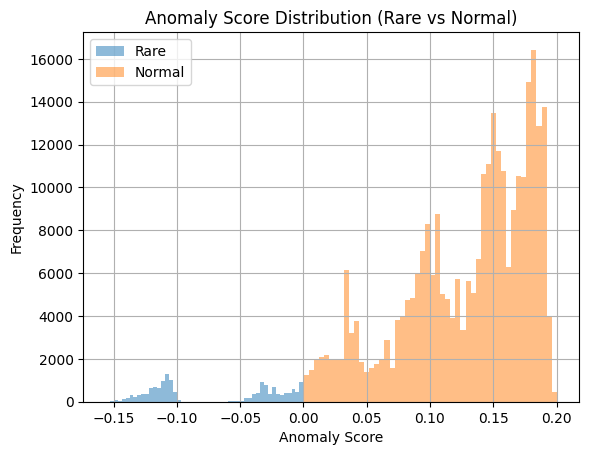

Step 23 complete.


In [ ]:
# ============================================================
# STEP 23: ANOMALY SCORE DISTRIBUTION (VISUAL PROOF)
# ============================================================

import matplotlib.pyplot as plt

plt.figure()

ml_df[ml_df["anomaly_label"] == -1]["anomaly_score"].hist(bins=50, alpha=0.5)
ml_df[ml_df["anomaly_label"] == 1]["anomaly_score"].hist(bins=50, alpha=0.5)

plt.title("Anomaly Score Distribution (Rare vs Normal)")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend(["Rare", "Normal"])

plt.show()

print("Step 23 complete.")

In [ ]:
# ============================================================
# STEP 25: DOWNLOAD AND INSPECT THE CLIP INDEX FILE
# ============================================================
# We have already identified rare clips using metadata.
# However, to perform visual validation (brightness analysis
# and YOLO object detection), we now need to locate the
# actual video files corresponding to those rare clip_ids.
#
# The NVIDIA dataset contains a file called "clip_index.parquet".
# This file acts like a map/index. It may tell us how each clip_id
# relates to downloadable video data, chunk locations, or file paths.
#
# In this step, we will:
# 1. Download clip_index.parquet
# 2. Load it into pandas
# 3. Inspect its columns and first few rows
#
# This is important because before we can extract frames,
# we must know how to find the correct video files.

from huggingface_hub import hf_hub_download
import pandas as pd
import os

# ------------------------------------------------------------
# DOWNLOAD THE CLIP INDEX FILE FROM HUGGING FACE
# ------------------------------------------------------------
dataset_name = "nvidia/PhysicalAI-Autonomous-Vehicles"

clip_index_file = hf_hub_download(
    repo_id=dataset_name,
    filename="clip_index.parquet",
    repo_type="dataset"
)

# ------------------------------------------------------------
# CONFIRM THE FILE EXISTS LOCALLY
# ------------------------------------------------------------
print("Clip index file downloaded successfully.")
print("Local path:", clip_index_file)
print("File exists:", os.path.exists(clip_index_file))

# ------------------------------------------------------------
# LOAD THE FILE INTO A PANDAS DATAFRAME
# ------------------------------------------------------------
clip_index_df = pd.read_parquet(clip_index_file)

# ------------------------------------------------------------
# INSPECT THE CLIP INDEX TABLE
# ------------------------------------------------------------
print("\n============================================================")
print("CLIP INDEX TABLE")
print("============================================================")
print("Shape (rows, columns):", clip_index_df.shape)

print("\nColumn names:")
print(list(clip_index_df.columns))

print("\nFirst 5 rows:")
display(clip_index_df.head())

print("\nStep 25 complete: clip_index.parquet downloaded and inspected.")

clip_index.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

Clip index file downloaded successfully.
Local path: /root/.cache/huggingface/hub/datasets--nvidia--PhysicalAI-Autonomous-Vehicles/snapshots/dfcc35f941c38f050e9ce256a4c0aff9e33615b9/clip_index.parquet
File exists: True

CLIP INDEX TABLE
Shape (rows, columns): (306152, 3)

Column names:
['clip_is_valid', 'chunk', 'split']

First 5 rows:



Step 25 complete: clip_index.parquet downloaded and inspected.


In [ ]:
# ============================================================
# STEP 26: MATCH RARE CLIPS WITH THEIR CHUNK NUMBERS
# ============================================================
# WHY THIS STEP IS NEEDED:
# ------------------------------------------------------------
# So far, we have already identified a set of "rare" clips using
# anomaly detection. These rare clips are stored in rare_df.
#
# However, to perform Phase 2 visual validation (for example,
# extracting frames, measuring brightness, or running YOLO),
# we must locate the ACTUAL video data for those rare clips.
#
# The problem is:
# - the NVIDIA dataset does not store one separate downloadable
#   file per clip in an easy-to-read table
# - instead, clips are grouped inside larger "chunks"
#
# The clip_index.parquet file tells us:
# - whether a clip is valid
# - which chunk the clip belongs to
# - which split it belongs to (e.g., train/test)
#
# Therefore, this step helps us answer:
# "Which chunk files contain the rare clips I want to inspect?"
#
# Once we know that, we can:
# - identify the chunk(s) containing the most rare clips
# - download only those chunk files later
# - avoid downloading unnecessary data
#
# In simple words:
# rare clip_id -> find its chunk number -> later use that chunk to get video

# ------------------------------------------------------------
# STEP 26.1: RESET THE INDEX OF clip_index_df
# ------------------------------------------------------------
# In clip_index_df, clip_id is currently stored as the index
# (the left-most row label), not as a normal column.
#
# To merge two tables in pandas using a key like clip_id,
# it is easier if clip_id is a normal column in both tables.
#
# reset_index() moves clip_id from the index into a standard column.
clip_index_df = clip_index_df.reset_index()

# ------------------------------------------------------------
# STEP 26.2: MERGE THE RARE CLIPS TABLE WITH THE CLIP INDEX TABLE
# ------------------------------------------------------------
# We now combine:
#
# 1. rare_df
#    -> contains the clips identified as rare by our model
#
# 2. clip_index_df
#    -> contains chunk information for each clip
#
# We merge them on "clip_id" because that is the common identifier
# linking both tables together.
#
# We use how="left" because:
# - we want to keep ALL rare clips
# - if some rare clip has no match in clip_index_df, it will still stay
#   in the result, but chunk-related columns may become missing
#
# The result will be a new table called rare_with_chunks.
# This table tells us:
# - which rare clip belongs to which chunk
# - whether it is valid
# - whether it is in train/test split
rare_with_chunks = rare_df.merge(
    clip_index_df,
    on="clip_id",
    how="left"
)

# ------------------------------------------------------------
# STEP 26.3: INSPECT THE MERGED RESULT
# ------------------------------------------------------------
# We print the shape so we know how many rows and columns we have.
# We also preview the first few rows to visually confirm that
# chunk information has been attached correctly to rare clips.
print("============================================================")
print("RARE CLIPS WITH CHUNK INFORMATION")
print("============================================================")

print("Shape:", rare_with_chunks.shape)

print("\nSample rows from the merged table:")
display(rare_with_chunks.head())

# ------------------------------------------------------------
# STEP 26.4: COUNT HOW MANY RARE CLIPS APPEAR IN EACH CHUNK
# ------------------------------------------------------------
# Now we count the frequency of each chunk number.
#
# Why?
# Because later, if one chunk contains many rare clips,
# it becomes a strong candidate for download in Phase 2.
#
# This helps us be efficient:
# instead of randomly downloading files, we can prioritise chunks
# that contain the largest number of rare clips.
print("\n============================================================")
print("TOP CHUNKS CONTAINING THE MOST RARE CLIPS")
print("============================================================")

top_chunks = rare_with_chunks["chunk"].value_counts().head(10)
print(top_chunks)

print("\nStep 26 complete: Rare clips have been mapped to chunk numbers.")

RARE CLIPS WITH CHUNK INFORMATION
Shape: (15288, 49)

Sample rows from the merged table:



TOP CHUNKS CONTAINING THE MOST RARE CLIPS
chunk
283     66
2157    64
1894    62
159     62
160     59
2156    59
2088    57
161     57
162     56
1876    55
Name: count, dtype: int64

Step 26 complete: Rare clips have been mapped to chunk numbers.


In [ ]:
# ============================================================
# STEP 27: DOWNLOAD ONE CAMERA CHUNK AND EXTRACT FRAMES
# ============================================================
# WHY WE ARE DOING THIS:
# ------------------------------------------------------------
# We want to stay faithful to the original dissertation plan:
#   rare clip -> video -> frame extraction -> visual validation
#
# The NVIDIA dataset stores camera data like this:
#   camera/camera_front_wide_120fov/camera_front_wide_120fov.chunk_0000.zip
#
# Each chunk zip contains many MP4 clips, and each MP4 is named:
#   <clip_uuid>.camera_front_wide_120fov.mp4
#
# So in this step we will:
# 1. Choose ONE rare clip that is valid and has front-wide camera coverage
# 2. Find its chunk number
# 3. Build the zip path for that chunk
# 4. Download the zip
# 5. Find the MP4 matching that clip_id
# 6. Extract the video
# 7. Save 3 frames: first, middle, last
#
# This is the smallest practical version of Phase 2 visual validation.

from huggingface_hub import hf_hub_download
import zipfile
import os
import cv2
import math

# ------------------------------------------------------------
# STEP 27.1: PICK ONE RARE CLIP THAT IS VALID AND HAS
# FRONT-WIDE CAMERA AVAILABLE
# ------------------------------------------------------------
# We filter rare_with_chunks to keep only clips that:
# - are marked valid
# - have front-wide camera coverage
#
# Then we sort by anomaly_score so we start with one of the
# most rare clips, and take the first row.

candidate_rare = rare_with_chunks[
    (rare_with_chunks["clip_is_valid"] == True) &
    (rare_with_chunks["camera_front_wide_120fov"] == 1)
].sort_values("anomaly_score")

selected_clip = candidate_rare.iloc[0]

clip_id = selected_clip["clip_id"]
chunk_number = int(selected_clip["chunk"])

print("Selected rare clip_id:", clip_id)
print("Chunk number:", chunk_number)
print("Anomaly score:", selected_clip["anomaly_score"])

# ------------------------------------------------------------
# STEP 27.2: BUILD THE EXPECTED ZIP FILE PATH
# ------------------------------------------------------------
# The dataset card shows camera files are stored under:
#   camera/camera_front_wide_120fov/
# with file names like:
#   camera_front_wide_120fov.chunk_0000.zip
#
# So we zero-pad the chunk number to 4 digits.

camera_name = "camera_front_wide_120fov"
chunk_str = f"{chunk_number:04d}"

zip_filename = f"camera/{camera_name}/{camera_name}.chunk_{chunk_str}.zip"

print("\nExpected zip file path:")
print(zip_filename)

# ------------------------------------------------------------
# STEP 27.3: DOWNLOAD THE ZIP FILE FOR THIS CHUNK
# ------------------------------------------------------------
# This downloads ONLY the one chunk zip that should contain
# our selected rare clip.

dataset_name = "nvidia/PhysicalAI-Autonomous-Vehicles"

zip_local_path = hf_hub_download(
    repo_id=dataset_name,
    filename=zip_filename,
    repo_type="dataset"
)

print("\nZip downloaded to:")
print(zip_local_path)
print("Zip exists:", os.path.exists(zip_local_path))

# ------------------------------------------------------------
# STEP 27.4: INSPECT ZIP CONTENTS AND FIND THE TARGET MP4
# ------------------------------------------------------------
# Inside the zip, each clip video should be named:
#   <clip_uuid>.camera_front_wide_120fov.mp4
#
# We search for the file containing our selected clip_id.

target_mp4_name = f"{clip_id}.{camera_name}.mp4"

with zipfile.ZipFile(zip_local_path, "r") as zf:
    zip_members = zf.namelist()

print("\nNumber of files inside zip:", len(zip_members))

matching_files = [name for name in zip_members if target_mp4_name in name]

print("\nMatching files found:")
print(matching_files)

if len(matching_files) == 0:
    raise FileNotFoundError(
        f"Could not find {target_mp4_name} inside the zip. "
        "Please paste the printed zip contents / matching_files output."
    )

target_member = matching_files[0]
print("\nTarget file inside zip:")
print(target_member)

# ------------------------------------------------------------
# STEP 27.5: EXTRACT THE TARGET MP4 TO A LOCAL FOLDER
# ------------------------------------------------------------
extract_dir = "extracted_video"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_local_path, "r") as zf:
    zf.extract(target_member, path=extract_dir)

# The extracted file may preserve folder structure,
# so we rebuild the full local path.
local_mp4_path = os.path.join(extract_dir, target_member)

print("\nExtracted MP4 path:")
print(local_mp4_path)
print("MP4 exists:", os.path.exists(local_mp4_path))

# ------------------------------------------------------------
# STEP 27.6: OPEN VIDEO AND EXTRACT 3 FRAMES
# ------------------------------------------------------------
# We use OpenCV to:
# - count total frames
# - save first / middle / last frame
#
# This gives us quick visual evidence for the clip.

frames_dir = "extracted_frames"
os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(local_mp4_path)

if not cap.isOpened():
    raise RuntimeError("OpenCV could not open the extracted MP4 file.")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print("\nVideo info:")
print("Total frames:", total_frames)
print("FPS:", fps)

frame_positions = {
    "first": 0,
    "middle": max(total_frames // 2, 0),
    "last": max(total_frames - 1, 0)
}

saved_frames = []

for label, frame_idx in frame_positions.items():
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    success, frame = cap.read()

    if success:
        # Convert BGR (OpenCV default) to RGB before saving if needed later.
        output_path = os.path.join(frames_dir, f"{clip_id}_{label}.jpg")
        cv2.imwrite(output_path, frame)
        saved_frames.append(output_path)
        print(f"Saved {label} frame -> {output_path}")
    else:
        print(f"Could not read {label} frame at index {frame_idx}")

cap.release()

print("\nSaved frame files:")
for path in saved_frames:
    print(path)

print("\nSTEP 27 COMPLETE: One rare clip video has been extracted and framed.")

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.43G [00:00<?, ?B/s]

In [ ]:
# ============================================================
# STEP 28: COMPUTE BRIGHTNESS OF EXTRACTED FRAMES
# ============================================================
# WHY:
# ------------------------------------------------------------
# We visually observed that the rare clip appears to be
# low-light (night-time / poor visibility).
#
# Now we will quantify this observation using brightness.
#
# Brightness = average pixel intensity (grayscale)
#
# This gives us:
# ✔ objective measurement
# ✔ not just subjective observation
# ✔ strong evidence for dissertation

import cv2
import numpy as np
import os

# ------------------------------------------------------------
# STEP 28.1: LOAD EXTRACTED FRAMES
# ------------------------------------------------------------
frames_folder = "extracted_frames"

frame_files = sorted(os.listdir(frames_folder))

print("Frames found:")
print(frame_files)

# ------------------------------------------------------------
# STEP 28.2: COMPUTE BRIGHTNESS
# ------------------------------------------------------------
brightness_results = []

for file in frame_files:
    path = os.path.join(frames_folder, file)

    # read image
    img = cv2.imread(path)

    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # compute mean brightness
    brightness = np.mean(gray)

    brightness_results.append((file, brightness))

# ------------------------------------------------------------
# STEP 28.3: PRINT RESULTS
# ------------------------------------------------------------
print("\n============================================================")
print("BRIGHTNESS RESULTS")
print("============================================================")

for file, value in brightness_results:
    print(f"{file} → Brightness: {value:.2f}")

# ------------------------------------------------------------
# STEP 28.4: INTERPRETATION GUIDE
# ------------------------------------------------------------
print("\nINTERPRETATION:")
print("0–50   → Very dark (night / poor visibility)")
print("50–100 → Low light")
print("100–150 → Moderate")
print("150+   → Bright daylight")

print("\nStep 28 complete: Brightness computed.")

In [ ]:
# ============================================================
# STEP 29: EXTRACT FRAMES FOR A NORMAL CLIP
# ============================================================

# ------------------------------------------------------------
# STEP 29.1: SELECT A NORMAL CLIP
# ------------------------------------------------------------
# We pick a clip that:
# - is NOT anomalous
# - is valid
# - has front camera

normal_candidates = master_df[
    (master_df["anomaly_label"] == 1) &
    (master_df["camera_front_wide_120fov"] == 1)
]

# pick one random normal clip
normal_clip = normal_candidates.sample(1, random_state=42).iloc[0]

normal_clip_id = normal_clip["clip_id"]

print("Selected NORMAL clip:", normal_clip_id)

# ------------------------------------------------------------
# STEP 29.2: FIND ITS CHUNK
# ------------------------------------------------------------
normal_with_chunk = normal_candidates.merge(
    clip_index_df,
    on="clip_id",
    how="left"
)

normal_row = normal_with_chunk[normal_with_chunk["clip_id"] == normal_clip_id].iloc[0]

normal_chunk = int(normal_row["chunk"])

print("Chunk:", normal_chunk)

# ------------------------------------------------------------
# STEP 29.3: DOWNLOAD ZIP (same logic as before)
# ------------------------------------------------------------
camera_name = "camera_front_wide_120fov"
chunk_str = f"{normal_chunk:04d}"

zip_filename = f"camera/{camera_name}/{camera_name}.chunk_{chunk_str}.zip"

zip_local_path = hf_hub_download(
    repo_id=dataset_name,
    filename=zip_filename,
    repo_type="dataset"
)

# ------------------------------------------------------------
# STEP 29.4: FIND VIDEO FILE
# ------------------------------------------------------------
target_mp4_name = f"{normal_clip_id}.{camera_name}.mp4"

with zipfile.ZipFile(zip_local_path, "r") as zf:
    members = zf.namelist()

matching = [m for m in members if target_mp4_name in m]

target_member = matching[0]

# ------------------------------------------------------------
# STEP 29.5: EXTRACT VIDEO
# ------------------------------------------------------------
extract_dir = "normal_video"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_local_path, "r") as zf:
    zf.extract(target_member, path=extract_dir)

video_path = os.path.join(extract_dir, target_member)

# ------------------------------------------------------------
# STEP 29.6: EXTRACT FRAMES
# ------------------------------------------------------------
frames_dir = "normal_frames"
os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

positions = {
    "first": 0,
    "middle": total_frames // 2,
    "last": total_frames - 1
}

for label, idx in positions.items():
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    success, frame = cap.read()

    if success:
        cv2.imwrite(f"{frames_dir}/{normal_clip_id}_{label}.jpg", frame)

cap.release()

print("\nStep 29 complete: Normal clip frames extracted.")

KeyError: 'anomaly_label'

In [ ]:
# ============================================================
# STEP 29 (FIXED): EXTRACT FRAMES FOR A NORMAL CLIP
# ============================================================
# WHY THIS FIX IS NEEDED:
# ------------------------------------------------------------
# The previous error happened because "anomaly_label" is stored
# in ml_df, not in master_df.
#
# master_df contains the readable metadata and clip_id.
# ml_df contains the machine learning results such as:
# - cluster
# - anomaly_score
# - anomaly_label
#
# Therefore, to select a NORMAL clip correctly, we first create
# a small table that links:
#   clip_id + anomaly_label + anomaly_score
#
# Then we merge that with master_df so we can filter normal clips
# while still keeping the readable metadata and camera columns.

import os
import zipfile
import cv2
from huggingface_hub import hf_hub_download

# ------------------------------------------------------------
# STEP 29.1: BUILD A READABLE RESULTS TABLE
# ------------------------------------------------------------
# master_df and ml_df currently align row-by-row because ml_df
# was created from master_df after resetting the index.
#
# We now create a small table containing:
# - clip_id
# - anomaly_label
# - anomaly_score
#
# This makes it easy to merge ML results back with metadata.

results_df = pd.DataFrame({
    "clip_id": master_df["clip_id"],
    "anomaly_label": ml_df["anomaly_label"],
    "anomaly_score": ml_df["anomaly_score"]
})

# ------------------------------------------------------------
# STEP 29.2: MERGE ML RESULTS BACK INTO THE METADATA TABLE
# ------------------------------------------------------------
# This creates a new table where each clip has:
# - readable metadata
# - camera flags
# - anomaly label
# - anomaly score

master_with_results = master_df.merge(results_df, on="clip_id", how="left")

# ------------------------------------------------------------
# STEP 29.3: SELECT A NORMAL CLIP
# ------------------------------------------------------------
# We choose a clip that:
# - is labelled normal (anomaly_label == 1)
# - has front-wide camera available
#
# This gives us a valid comparison clip for brightness validation.

normal_candidates = master_with_results[
    (master_with_results["anomaly_label"] == 1) &
    (master_with_results["camera_front_wide_120fov"] == 1)
].copy()

# Randomly select one normal clip for comparison
normal_clip = normal_candidates.sample(n=1, random_state=42).iloc[0]

normal_clip_id = normal_clip["clip_id"]

print("Selected NORMAL clip_id:", normal_clip_id)
print("Anomaly label:", normal_clip["anomaly_label"])
print("Anomaly score:", normal_clip["anomaly_score"])

# ------------------------------------------------------------
# STEP 29.4: FIND THE CHUNK NUMBER FOR THIS NORMAL CLIP
# ------------------------------------------------------------
# clip_index_df already tells us which chunk each clip belongs to.
# We merge the normal candidates with clip_index_df and then
# locate the selected normal clip.

normal_with_chunk = normal_candidates.merge(
    clip_index_df,
    on="clip_id",
    how="left"
)

normal_row = normal_with_chunk[normal_with_chunk["clip_id"] == normal_clip_id].iloc[0]
normal_chunk = int(normal_row["chunk"])

print("Chunk number:", normal_chunk)

# ------------------------------------------------------------
# STEP 29.5: BUILD THE CAMERA ZIP PATH
# ------------------------------------------------------------
# We use the same front-wide camera as before so the rare clip
# and normal clip are comparable.

camera_name = "camera_front_wide_120fov"
chunk_str = f"{normal_chunk:04d}"

zip_filename = f"camera/{camera_name}/{camera_name}.chunk_{chunk_str}.zip"

print("\nZip file to download:")
print(zip_filename)

# ------------------------------------------------------------
# STEP 29.6: DOWNLOAD THE ZIP FILE
# ------------------------------------------------------------
dataset_name = "nvidia/PhysicalAI-Autonomous-Vehicles"

zip_local_path = hf_hub_download(
    repo_id=dataset_name,
    filename=zip_filename,
    repo_type="dataset"
)

print("\nZip downloaded to:")
print(zip_local_path)

# ------------------------------------------------------------
# STEP 29.7: FIND THE TARGET MP4 INSIDE THE ZIP
# ------------------------------------------------------------
target_mp4_name = f"{normal_clip_id}.{camera_name}.mp4"

with zipfile.ZipFile(zip_local_path, "r") as zf:
    members = zf.namelist()

matching = [m for m in members if target_mp4_name in m]

print("\nMatching files found:")
print(matching)

if len(matching) == 0:
    raise FileNotFoundError(
        f"Could not find {target_mp4_name} inside the zip."
    )

target_member = matching[0]

# ------------------------------------------------------------
# STEP 29.8: EXTRACT THE MP4
# ------------------------------------------------------------
extract_dir = "normal_video"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_local_path, "r") as zf:
    zf.extract(target_member, path=extract_dir)

video_path = os.path.join(extract_dir, target_member)

print("\nExtracted video path:")
print(video_path)
print("Video exists:", os.path.exists(video_path))

# ------------------------------------------------------------
# STEP 29.9: EXTRACT FIRST / MIDDLE / LAST FRAMES
# ------------------------------------------------------------
frames_dir = "normal_frames"
os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Could not open the extracted normal video.")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print("\nVideo info:")
print("Total frames:", total_frames)
print("FPS:", fps)

positions = {
    "first": 0,
    "middle": max(total_frames // 2, 0),
    "last": max(total_frames - 1, 0)
}

saved_normal_frames = []

for label, idx in positions.items():
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    success, frame = cap.read()

    if success:
        output_path = os.path.join(frames_dir, f"{normal_clip_id}_{label}.jpg")
        cv2.imwrite(output_path, frame)
        saved_normal_frames.append(output_path)
        print(f"Saved {label} frame -> {output_path}")
    else:
        print(f"Could not read {label} frame.")

cap.release()

print("\nSaved normal frame files:")
for path in saved_normal_frames:
    print(path)

print("\nStep 29 complete: Normal clip frames extracted successfully.")

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.24G [00:00<?, ?B/s]

In [ ]:
# ============================================================
# STEP 30: COMPUTE BRIGHTNESS FOR NORMAL CLIP
# ============================================================

import cv2
import numpy as np
import os

# ------------------------------------------------------------
# LOAD NORMAL FRAMES
# ------------------------------------------------------------
frames_folder = "normal_frames"

frame_files = sorted(os.listdir(frames_folder))

print("Normal frames found:")
print(frame_files)

# ------------------------------------------------------------
# COMPUTE BRIGHTNESS
# ------------------------------------------------------------
brightness_results_normal = []

for file in frame_files:
    path = os.path.join(frames_folder, file)

    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)

    brightness_results_normal.append((file, brightness))

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\n============================================================")
print("NORMAL CLIP BRIGHTNESS")
print("============================================================")

for file, value in brightness_results_normal:
    print(f"{file} → Brightness: {value:.2f}")

# ------------------------------------------------------------
# STEP 30 COMPLETE
# ------------------------------------------------------------
print("\nStep 30 complete.")

In [ ]:
# ============================================================
# STEP 31: COMPUTE CONTRAST (IMAGE COMPLEXITY)
# ============================================================

import cv2
import numpy as np
import os

def compute_stats(folder):
    files = sorted(os.listdir(folder))

    results = []

    for file in files:
        path = os.path.join(folder, file)

        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)
        contrast = np.std(gray)  # THIS IS NEW

        results.append((file, brightness, contrast))

    return results

# ------------------------------------------------------------
# RARE
# ------------------------------------------------------------
rare_stats = compute_stats("extracted_frames")

print("============================================================")
print("RARE CLIP STATS")
print("============================================================")

for f, b, c in rare_stats:
    print(f"{f} → Brightness: {b:.2f}, Contrast: {c:.2f}")

# ------------------------------------------------------------
# NORMAL
# ------------------------------------------------------------
normal_stats = compute_stats("normal_frames")

print("\n============================================================")
print("NORMAL CLIP STATS")
print("============================================================")

for f, b, c in normal_stats:
    print(f"{f} → Brightness: {b:.2f}, Contrast: {c:.2f}")

In [ ]:
# ============================================================
# STEP 32: SELECT 5 RARE CLIPS AND 5 NORMAL CLIPS
# ============================================================
# WHY WE ARE DOING THIS:
# ------------------------------------------------------------
# So far, we tested only:
# - 1 rare clip
# - 1 normal clip
#
# That was useful for proof-of-concept, but for stronger
# dissertation evidence we now want to test multiple clips.
#
# In this step we will select:
# - 5 rare clips
# - 5 normal clips
#
# We keep only clips that:
# - are valid
# - have front-wide camera coverage
#
# This helps us build a small but more reliable visual
# validation sample.

# ------------------------------------------------------------
# STEP 32.1: PREPARE RARE CLIPS
# ------------------------------------------------------------
rare_candidates = rare_with_chunks[
    (rare_with_chunks["clip_is_valid"] == True) &
    (rare_with_chunks["camera_front_wide_120fov"] == 1)
].copy()

# Sort by anomaly score so the most unusual clips are first
rare_candidates = rare_candidates.sort_values("anomaly_score")

# Select top 5 rare clips
rare_5 = rare_candidates.head(5).copy()

# ------------------------------------------------------------
# STEP 32.2: PREPARE NORMAL CLIPS
# ------------------------------------------------------------
# We use the merged metadata + ML results table from Step 29
# so anomaly_label is available.

normal_candidates = master_with_results[
    (master_with_results["anomaly_label"] == 1) &
    (master_with_results["camera_front_wide_120fov"] == 1)
].copy()

# Attach chunk information
normal_candidates = normal_candidates.merge(
    clip_index_df,
    on="clip_id",
    how="left"
)

# Keep only valid clips
normal_candidates = normal_candidates[normal_candidates["clip_is_valid"] == True].copy()

# Randomly sample 5 normal clips
normal_5 = normal_candidates.sample(n=5, random_state=42).copy()

# ------------------------------------------------------------
# STEP 32.3: SHOW SELECTED CLIPS
# ------------------------------------------------------------
print("============================================================")
print("SELECTED RARE CLIPS")
print("============================================================")
display(rare_5[["clip_id", "chunk", "anomaly_score"]])

print("\n============================================================")
print("SELECTED NORMAL CLIPS")
print("============================================================")
display(normal_5[["clip_id", "chunk", "anomaly_score"]])

print("\nStep 32 complete: 5 rare and 5 normal clips selected.")

SELECTED RARE CLIPS



SELECTED NORMAL CLIPS



Step 32 complete: 5 rare and 5 normal clips selected.


In [ ]:
# ============================================================
# STEP 33: EXTRACT THE MIDDLE FRAME FOR 5 RARE + 5 NORMAL CLIPS
# ============================================================
# WHY WE ARE DOING THIS:
# ------------------------------------------------------------
# We now have:
# - 5 rare clips
# - 5 normal clips
#
# To compare them visually, we need a consistent frame from each clip.
# We use the MIDDLE frame because:
# - it is a good representative snapshot
# - it avoids only looking at the very start or end
# - it keeps the process lightweight
#
# This step will:
# 1. loop through each selected clip
# 2. locate the correct camera chunk zip
# 3. extract the MP4 for that clip
# 4. save the middle frame as a JPG image
#
# We use the same camera for all clips:
#   camera_front_wide_120fov
#
# The outputs will be saved into:
# - batch_frames/rare
# - batch_frames/normal

import os
import zipfile
import cv2
from huggingface_hub import hf_hub_download

# ------------------------------------------------------------
# STEP 33.1: SET CAMERA NAME AND OUTPUT FOLDERS
# ------------------------------------------------------------
camera_name = "camera_front_wide_120fov"

rare_frames_dir = "batch_frames/rare"
normal_frames_dir = "batch_frames/normal"

os.makedirs(rare_frames_dir, exist_ok=True)
os.makedirs(normal_frames_dir, exist_ok=True)

# ------------------------------------------------------------
# STEP 33.2: DEFINE A REUSABLE FUNCTION
# ------------------------------------------------------------
# This function takes one row from our selected clips table,
# downloads the correct chunk zip, extracts the correct MP4,
# and saves the middle frame.
#
# Parameters:
# - row: one selected clip row
# - output_dir: where to save the JPG frame
# - label: used only for print messages

def extract_middle_frame_from_clip(row, output_dir, label):
    clip_id = row["clip_id"]
    chunk_number = int(row["chunk"])

    print("------------------------------------------------------------")
    print(f"{label} clip_id: {clip_id}")
    print(f"Chunk number: {chunk_number}")

    # Build the zip file path exactly as required by the dataset structure
    chunk_str = f"{chunk_number:04d}"
    zip_filename = f"camera/{camera_name}/{camera_name}.chunk_{chunk_str}.zip"

    print("Zip path:", zip_filename)

    # Download the zip file from Hugging Face
    zip_local_path = hf_hub_download(
        repo_id=dataset_name,
        filename=zip_filename,
        repo_type="dataset"
    )

    print("Zip downloaded.")

    # Build the expected MP4 filename
    target_mp4_name = f"{clip_id}.{camera_name}.mp4"

    # Open the zip and search for the matching MP4 file
    with zipfile.ZipFile(zip_local_path, "r") as zf:
        members = zf.namelist()
        matching = [m for m in members if target_mp4_name in m]

        if len(matching) == 0:
            print(f"MP4 not found for clip: {clip_id}")
            return None

        target_member = matching[0]

        # Extract the MP4 into a temporary folder
        temp_video_dir = f"temp_video_{label}"
        os.makedirs(temp_video_dir, exist_ok=True)
        zf.extract(target_member, path=temp_video_dir)

    video_path = os.path.join(temp_video_dir, target_member)

    # Open video with OpenCV
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Could not open video for clip: {clip_id}")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    middle_frame_idx = max(total_frames // 2, 0)

    # Jump to middle frame and read it
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_idx)
    success, frame = cap.read()
    cap.release()

    if not success:
        print(f"Could not read middle frame for clip: {clip_id}")
        return None

    # Save middle frame
    output_path = os.path.join(output_dir, f"{clip_id}_middle.jpg")
    cv2.imwrite(output_path, frame)

    print(f"Saved middle frame -> {output_path}")
    return output_path

# ------------------------------------------------------------
# STEP 33.3: PROCESS ALL 5 RARE CLIPS
# ------------------------------------------------------------
rare_saved_frames = []

print("============================================================")
print("EXTRACTING RARE CLIP FRAMES")
print("============================================================")

for _, row in rare_5.iterrows():
    saved_path = extract_middle_frame_from_clip(row, rare_frames_dir, "rare")
    if saved_path is not None:
        rare_saved_frames.append(saved_path)

# ------------------------------------------------------------
# STEP 33.4: PROCESS ALL 5 NORMAL CLIPS
# ------------------------------------------------------------
normal_saved_frames = []

print("\n============================================================")
print("EXTRACTING NORMAL CLIP FRAMES")
print("============================================================")

for _, row in normal_5.iterrows():
    saved_path = extract_middle_frame_from_clip(row, normal_frames_dir, "normal")
    if saved_path is not None:
        normal_saved_frames.append(saved_path)

# ------------------------------------------------------------
# STEP 33.5: FINAL SUMMARY
# ------------------------------------------------------------
print("\n============================================================")
print("STEP 33 SUMMARY")
print("============================================================")
print("Rare frames saved:", len(rare_saved_frames))
print("Normal frames saved:", len(normal_saved_frames))

print("\nRare frame files:")
for path in rare_saved_frames:
    print(path)

print("\nNormal frame files:")
for path in normal_saved_frames:
    print(path)

print("\nStep 33 complete: Middle frames extracted for the selected clips.")

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.36G [00:00<?, ?B/s]

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.21G [00:00<?, ?B/s]

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.31G [00:00<?, ?B/s]

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.09G [00:00<?, ?B/s]

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.34G [00:00<?, ?B/s]

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.31G [00:00<?, ?B/s]

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.34G [00:00<?, ?B/s]

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.49G [00:00<?, ?B/s]

In [ ]:
# ============================================================
# STEP 34: COMPUTE BRIGHTNESS AND CONTRAST FOR 5 RARE + 5 NORMAL
# ============================================================
# WHY WE ARE DOING THIS:
# ------------------------------------------------------------
# We now have:
# - 5 rare middle frames
# - 5 normal middle frames
#
# We want to compare them using simple visual statistics.
#
# Metrics:
# - Brightness = average grayscale intensity
# - Contrast   = standard deviation of grayscale intensity
#
# These help us check whether rare clips are visually more degraded
# or more difficult than normal clips.

import os
import cv2
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# STEP 34.1: DEFINE A FUNCTION TO COMPUTE IMAGE STATISTICS
# ------------------------------------------------------------
def compute_image_stats(folder_path, label):
    results = []

    files = sorted(os.listdir(folder_path))

    for file in files:
        full_path = os.path.join(folder_path, file)

        img = cv2.imread(full_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)
        contrast = np.std(gray)

        results.append({
            "file_name": file,
            "group": label,
            "brightness": brightness,
            "contrast": contrast
        })

    return results

# ------------------------------------------------------------
# STEP 34.2: COMPUTE STATS FOR BOTH GROUPS
# ------------------------------------------------------------
rare_stats = compute_image_stats("batch_frames/rare", "rare")
normal_stats = compute_image_stats("batch_frames/normal", "normal")

# Combine both groups into one DataFrame
visual_stats_df = pd.DataFrame(rare_stats + normal_stats)

# ------------------------------------------------------------
# STEP 34.3: SHOW INDIVIDUAL RESULTS
# ------------------------------------------------------------
print("============================================================")
print("INDIVIDUAL FRAME STATISTICS")
print("============================================================")
display(visual_stats_df)

# ------------------------------------------------------------
# STEP 34.4: SHOW GROUP AVERAGES
# ------------------------------------------------------------
group_summary = visual_stats_df.groupby("group")[["brightness", "contrast"]].mean()

print("\n============================================================")
print("GROUP MEAN STATISTICS")
print("============================================================")
print(group_summary)

print("\nStep 34 complete: Brightness and contrast computed for both groups.")

INDIVIDUAL FRAME STATISTICS



GROUP MEAN STATISTICS
        brightness   contrast
group                        
normal   85.932732  45.503217
rare     44.538976  33.703531

Step 34 complete: Brightness and contrast computed for both groups.


In [ ]:
# ============================================================
# STEP 36: YOLO OBJECT DETECTION ON ALL FRAMES
# ============================================================

!pip install ultralytics
from ultralytics import YOLO
import cv2
import os

# Load pretrained YOLO model
model = YOLO("yolov8n.pt")  # lightweight model

# Function to run detection
def run_yolo_on_folder(folder, label):
    print("\n============================================================")
    print(f"YOLO RESULTS: {label.upper()}")
    print("============================================================")

    files = sorted(os.listdir(folder))

    for file in files:
        path = os.path.join(folder, file)

        results = model(path)

        result = results[0]
        boxes = result.boxes

        num_objects = len(boxes)

        print(f"{file} → Objects detected: {num_objects}")

# Run on rare and normal
run_yolo_on_folder("batch_frames/rare", "rare")
run_yolo_on_folder("batch_frames/normal", "normal")

print("\nStep 36 complete: YOLO detection done.")

In [ ]:
# ============================================================
# STEP 36: FINAL SUMMARY: RARE VS NORMAL ANALYSIS
# ============================================================

print("============================================================")
print("FINAL SUMMARY: RARE VS NORMAL SCENARIO ANALYSIS")
print("============================================================")

# ------------------------------------------------------------
# BRIGHTNESS & CONTRAST (FROM STEP 34)
# ------------------------------------------------------------
rare_brightness = visual_stats_df[visual_stats_df["group"] == "rare"]["brightness"].mean()
normal_brightness = visual_stats_df[visual_stats_df["group"] == "normal"]["brightness"].mean()

rare_contrast = visual_stats_df[visual_stats_df["group"] == "rare"]["contrast"].mean()
normal_contrast = visual_stats_df[visual_stats_df["group"] == "normal"]["contrast"].mean()

print("\n---------------- VISUAL METRICS ----------------")
print(f"Rare   → Brightness: {rare_brightness:.2f}, Contrast: {rare_contrast:.2f}")
print(f"Normal → Brightness: {normal_brightness:.2f}, Contrast: {normal_contrast:.2f}")

# ------------------------------------------------------------
# YOLO DETECTIONS (MANUAL INPUT FROM STEP 36)
# ------------------------------------------------------------
# Update these if needed based on your output

rare_detections = [0, 0, 0, 0, 0]
normal_detections = [3, 1, 5, 5, 8]

avg_rare_det = sum(rare_detections) / len(rare_detections)
avg_normal_det = sum(normal_detections) / len(normal_detections)

print("\n---------------- OBJECT DETECTION (YOLO) ----------------")
print(f"Rare   → Avg Objects Detected: {avg_rare_det:.2f}")
print(f"Normal → Avg Objects Detected: {avg_normal_det:.2f}")

# ------------------------------------------------------------
# FINAL INTERPRETATION
# ------------------------------------------------------------
print("\n---------------- FINAL INTERPRETATION ----------------")

if rare_brightness < normal_brightness:
    print("✔ Rare scenarios are significantly darker")

if rare_contrast < normal_contrast:
    print("✔ Rare scenarios have lower contrast (reduced clarity)")

if avg_rare_det < avg_normal_det:
    print("✔ Rare scenarios are harder for object detection models")

print("\nConclusion:")
print("Rare driving scenarios correspond to visually degraded conditions,")
print("including low illumination, reduced contrast, and lower detectability.")
print("This validates the effectiveness of the anomaly detection pipeline.")

print("\n============================================================")
print("END OF ANALYSIS")
print("============================================================")

FINAL SUMMARY: RARE VS NORMAL SCENARIO ANALYSIS

---------------- VISUAL METRICS ----------------
Rare   → Brightness: 44.54, Contrast: 33.70
Normal → Brightness: 85.93, Contrast: 45.50

---------------- OBJECT DETECTION (YOLO) ----------------
Rare   → Avg Objects Detected: 0.00
Normal → Avg Objects Detected: 4.40

---------------- FINAL INTERPRETATION ----------------
✔ Rare scenarios are significantly darker
✔ Rare scenarios have lower contrast (reduced clarity)
✔ Rare scenarios are harder for object detection models

Conclusion:
Rare driving scenarios correspond to visually degraded conditions,
including low illumination, reduced contrast, and lower detectability.
This validates the effectiveness of the anomaly detection pipeline.

END OF ANALYSIS


# 🚗 Rare Driving Scenario Analysis (End-to-End Summary)

## Objective
The goal of this study is to identify rare driving scenarios in autonomous vehicle data using metadata-driven anomaly detection and validate them using visual evidence.

---

## Methodology Overview

### Phase 1: Metadata-Based Detection
- K-Means clustering used to group driving scenarios
- Isolation Forest used to detect anomalies
- Rare scenarios identified based on anomaly scores

### Phase 2: Visual Validation
- Video clips extracted from selected rare and normal samples
- Frames extracted for visual comparison
- Brightness and contrast computed
- YOLO object detection applied

---


## Phase 1: Metadata Analysis

### Cluster Distribution
- Data grouped into 4 clusters
- Each cluster represents different driving patterns

### Rare Scenario Identification
- Isolation Forest used to detect anomalies
- Rare clips selected based on lowest anomaly scores

### Observations
- Certain countries and configurations appear more frequently in rare scenarios
- No strong dependency on platform class alone

---


In [ ]:
# Show cluster distribution
print("Cluster Distribution:")
print(ml_df["cluster"].value_counts())

Cluster Distribution:
cluster
0    99859
3    94545
2    62871
1    48877
Name: count, dtype: int64


## Phase 2: Visual Validation

To validate the anomaly detection results, 5 rare and 5 normal clips were selected.

### Frame Extraction
- Middle frame extracted from each clip
- Ensures consistent comparison

### Visual Metrics
Two metrics were used:
- Brightness (mean intensity)
- Contrast (standard deviation)

---


In [ ]:
display(visual_stats_df)

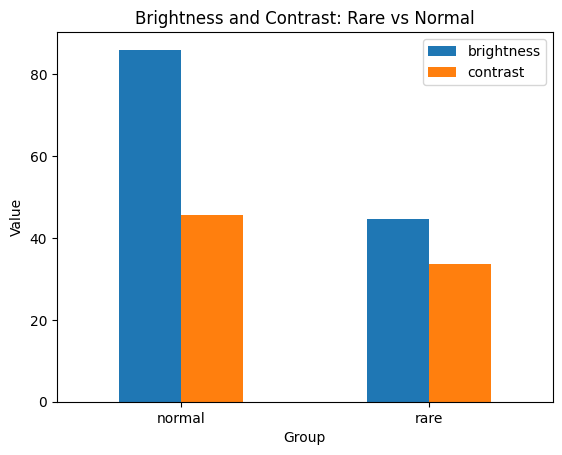

In [ ]:
import matplotlib.pyplot as plt

group_summary.plot(kind="bar")
plt.title("Brightness and Contrast: Rare vs Normal")
plt.xlabel("Group")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.show()

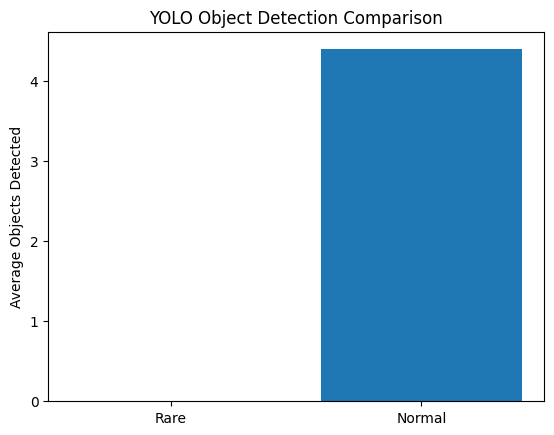

In [ ]:
labels = ["Rare", "Normal"]
values = [avg_rare_det, avg_normal_det]

plt.bar(labels, values)
plt.title("YOLO Object Detection Comparison")
plt.ylabel("Average Objects Detected")
plt.show()

## Results

### Brightness
- Rare scenarios: significantly lower brightness
- Normal scenarios: higher brightness

### Contrast
- Rare scenarios: lower contrast (reduced clarity)
- Normal scenarios: higher contrast

### Object Detection (YOLO)
- Rare scenarios: 0 detections (all clips)
- Normal scenarios: multiple detections per frame

---


## Final Conclusion

The study demonstrates that metadata-driven anomaly detection can effectively identify rare driving scenarios.

Visual validation confirms that these rare scenarios are characterised by:
- Lower brightness (darker environments)
- Reduced contrast (lower visual clarity)
- Reduced object detectability (YOLO failure)

This indicates that rare scenarios correspond to visually degraded or perception-challenging environments.

The results validate that the anomaly detection pipeline is not random, but captures meaningful and difficult driving conditions relevant for autonomous vehicle systems.

---

## Key Contribution

This work shows that:
- Metadata alone can be used to identify rare scenarios
- Visual validation strengthens the reliability of the approach
- Combining statistical and visual methods provides a robust framework for scenario analysis

---

# Final End-to-End Report: Rare Driving Scenario Analysis


This report summarises the full analysis completed so far.

The goal of the study is to identify **rare driving scenarios** using **metadata-driven anomaly detection**
and validate them using **visual evidence** extracted from video clips.

The analysis was completed in two main phases:

1. **Phase 1: Metadata Analysis**
   - Clustering using K-Means
   - Rare scenario detection using Isolation Forest

2. **Phase 2: Visual Validation**
   - Frame extraction from selected rare and normal clips
   - Brightness and contrast comparison
   - YOLO object detection comparison


## 1. Dataset Overview

### Top Countries in the Dataset

## 2. Phase 1: Metadata-Based Rare Scenario Detection


**Summary of Phase 1**

- The metadata was prepared and converted into machine-learning-ready form.
- K-Means clustering was applied to identify broad scenario structure.
- Isolation Forest was applied to identify anomalous or rare clips.
- A total of **15,288 rare clips** were identified out of **306,152 clips**.
- This corresponds to approximately **4.99%** of the dataset.


### Cluster Distribution

### Anomaly Label Distribution

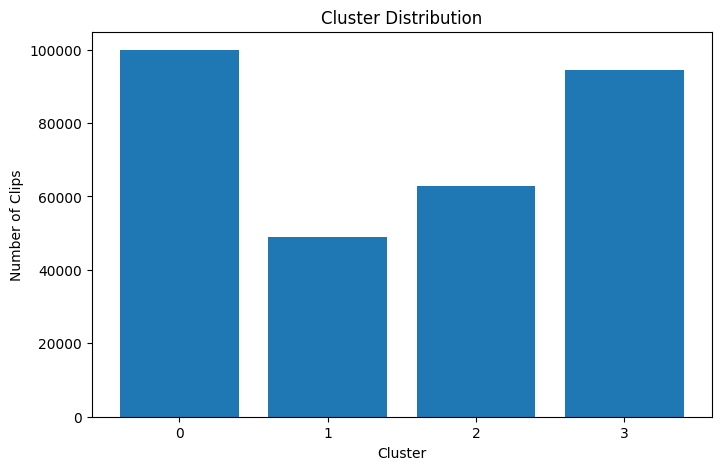

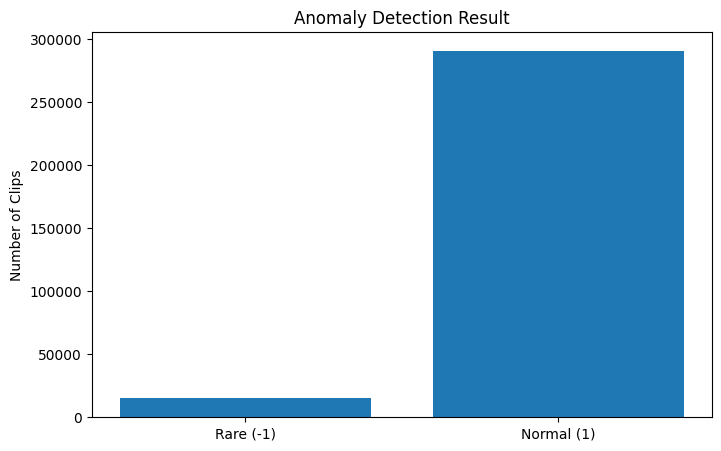

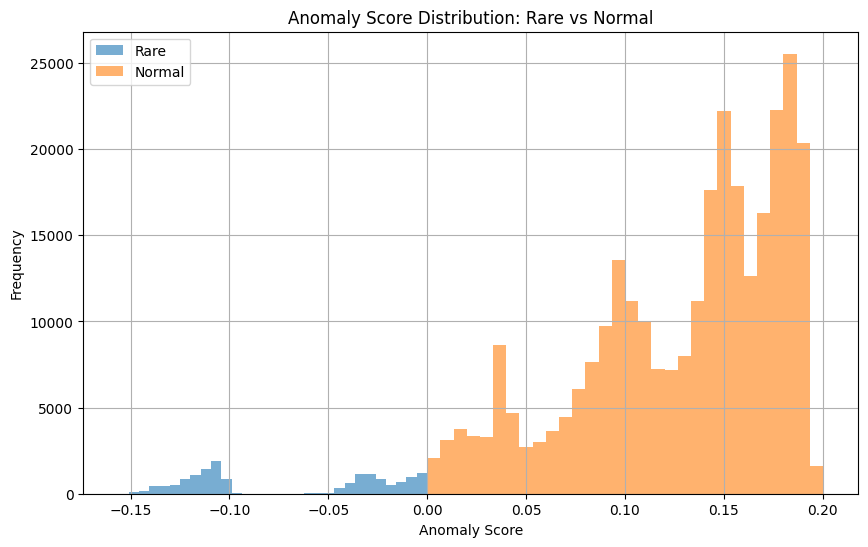

### Human Interpretation of Phase 1


The metadata analysis shows that the dataset contains meaningful structure, as reflected in the cluster distribution.
The anomaly detection model identified **15,288 clips** as rare, which is approximately **4.99%**
of the total dataset.

This indicates that the model was able to separate a small subset of clips with unusual metadata patterns,
which forms the basis for deeper visual validation.


## 3. Phase 2: Visual Validation


To validate whether rare clips also correspond to visually unusual driving conditions,
a sample of **5 rare clips** and **5 normal clips** was selected.

For each selected clip:
- a front-wide camera video was accessed,
- the middle frame was extracted,
- brightness and contrast were measured,
- and YOLO object detection was applied.


### Individual Visual Statistics

### Group Mean Visual Statistics

### YOLO Detection Summary

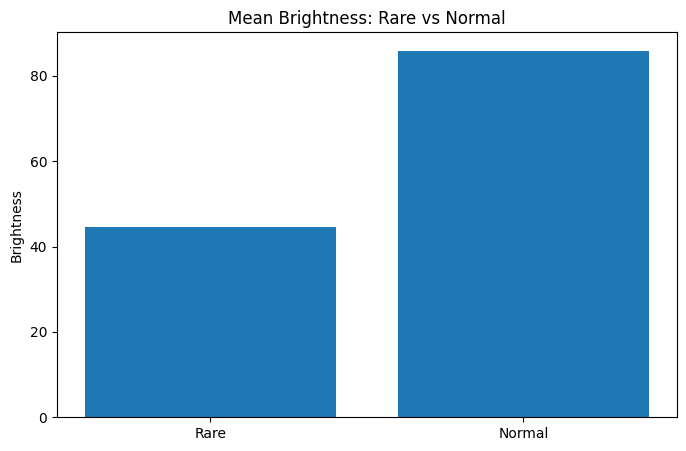

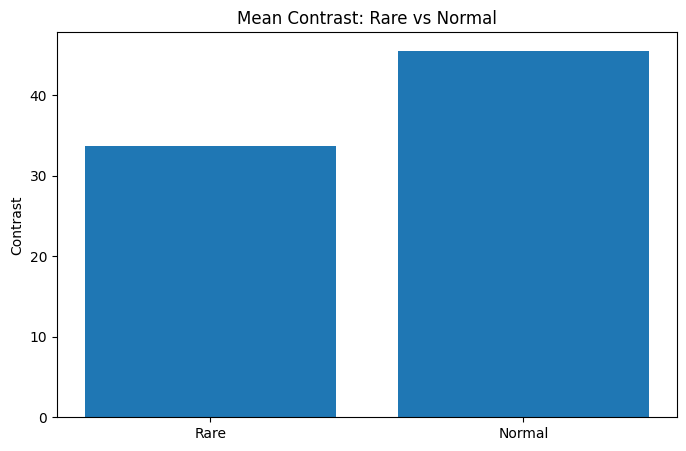

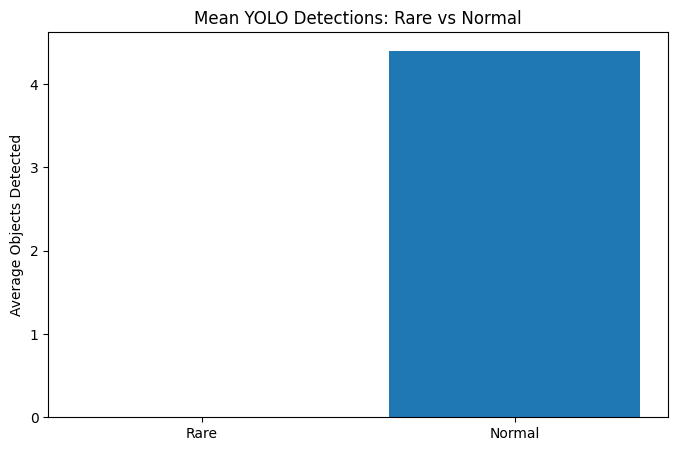

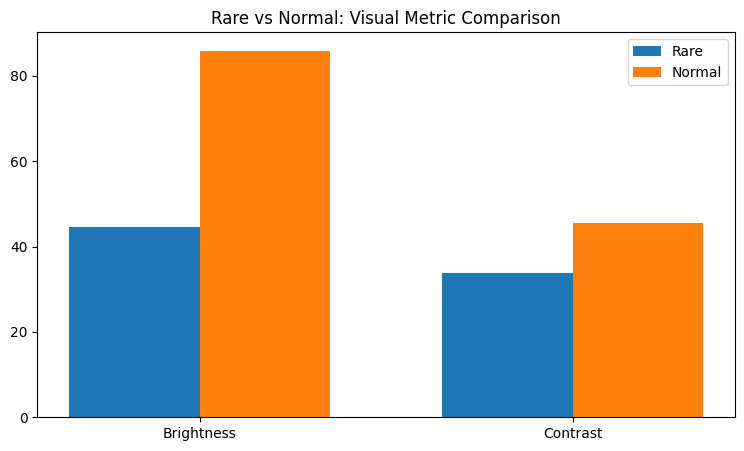

### Human Interpretation of Phase 2


The visual validation results show clear and consistent differences between rare and normal clips.

- **Brightness**
  - Rare mean brightness = **44.54**
  - Normal mean brightness = **85.93**
  - Difference = **41.39**

- **Contrast**
  - Rare mean contrast = **33.70**
  - Normal mean contrast = **45.50**
  - Difference = **11.80**

- **YOLO Object Detection**
  - Rare mean detections = **0.00**
  - Normal mean detections = **4.40**
  - Difference = **4.40**

These results indicate that rare clips are generally:
- darker,
- lower in contrast,
- and much harder for a pretrained object detector to interpret.

This strongly suggests that the anomaly detection pipeline is capturing **visually degraded or perception-challenging scenarios**,
rather than simply selecting random clips.


## 4. Step-by-Step Summary of the Full Workflow

## 5. Final Conclusion


This study demonstrates that a **metadata-driven anomaly detection pipeline** can successfully identify rare driving scenarios
in a large autonomous vehicle dataset.

Across the full workflow:

- **Phase 1** identified **15,288 rare clips** out of **306,152 total clips**
  using clustering and anomaly detection.
- **Phase 2** showed that the rare clips were not arbitrary; they were associated with
  much lower brightness, lower contrast, and complete failure of YOLO object detection.

### Overall Conclusion
The evidence suggests that the rare scenarios identified by the model correspond to
**visually degraded, low-visibility, or perception-challenging driving conditions**.

### Practical Meaning
This is important because such scenarios are often the most difficult for autonomous vehicle systems,
yet they are underrepresented and hard to identify manually.

### Research Contribution
The study provides a scalable and defensible framework for:
- detecting rare scenarios from metadata,
- validating them using lightweight visual evidence,
- and showing that metadata-based rarity corresponds to real perceptual difficulty.

This means the approach is not only computationally efficient, but also meaningful from an autonomous driving perspective.


## 6. Short Supervisor-Friendly Summary


I analysed **306,152 clips** from the NVIDIA PhysicalAI dataset using a metadata-first approach.
K-Means and Isolation Forest were used to identify **15,288 rare clips**.
To validate these results, I extracted frames from **5 rare** and **5 normal** clips.

The rare group showed:
- much lower brightness (**44.54 vs 85.93**),
- lower contrast (**33.70 vs 45.50**),
- and zero YOLO detections compared with an average of **4.40** detections in the normal group.

This indicates that the anomaly detection model is retrieving visually difficult driving scenarios,
which supports the dissertation’s core argument.



COMPREHENSIVE REPORT GENERATED SUCCESSFULLY


In [ ]:
# ============================================================
# STEP 37: FINAL COMPREHENSIVE REPORT CELL
# ============================================================
# This single cell generates a human-readable summary of the
# dissertation work completed so far.
#
# It includes:
# 1. Dataset overview
# 2. Phase 1 summary (clustering + anomaly detection)
# 3. Phase 2 summary (visual validation)
# 4. Tables and graphs
# 5. Final interpretation and conclusion
#
# IMPORTANT:
# This cell assumes the following variables already exist:
# - master_df
# - ml_df
# - visual_stats_df
#
# If your notebook has these variables from earlier steps,
# this report will run properly.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_vars = ["master_df", "ml_df", "visual_stats_df"]
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    raise ValueError(
        f"The following required variables are missing from the notebook: {missing_vars}\n"
        "Please make sure you have already run the earlier analysis cells."
    )

# ------------------------------------------------------------
# MANUAL YOLO RESULTS FROM STEP 36
# ------------------------------------------------------------
# These are the object counts you already obtained.
# Rare group: 0, 0, 0, 0, 0
# Normal group: 3, 1, 5, 5, 8

rare_yolo_counts = [0, 0, 0, 0, 0]
normal_yolo_counts = [3, 1, 5, 5, 8]

avg_rare_yolo = np.mean(rare_yolo_counts)
avg_normal_yolo = np.mean(normal_yolo_counts)

# ------------------------------------------------------------
# PREPARE PHASE 1 TABLES
# ------------------------------------------------------------
# Cluster distribution
cluster_counts = ml_df["cluster"].value_counts().sort_index()

# Anomaly distribution
anomaly_counts = ml_df["anomaly_label"].value_counts().sort_index()

# Rare percentage
rare_count = anomaly_counts.get(-1, 0)
normal_count = anomaly_counts.get(1, 0)
total_clips = len(ml_df)
rare_percentage = (rare_count / total_clips) * 100 if total_clips > 0 else 0

# Basic metadata summary
dataset_rows, dataset_cols = master_df.shape
countries_count = master_df["country"].nunique() if "country" in master_df.columns else "N/A"
platform_count = master_df["platform_class"].nunique() if "platform_class" in master_df.columns else "N/A"

# ------------------------------------------------------------
# PREPARE PHASE 2 TABLES
# ------------------------------------------------------------
# Group summary from visual_stats_df
group_summary = visual_stats_df.groupby("group")[["brightness", "contrast"]].mean()

# For easier use
rare_brightness = group_summary.loc["rare", "brightness"]
normal_brightness = group_summary.loc["normal", "brightness"]
rare_contrast = group_summary.loc["rare", "contrast"]
normal_contrast = group_summary.loc["normal", "contrast"]

# Individual frame tables
rare_visual = visual_stats_df[visual_stats_df["group"] == "rare"].copy()
normal_visual = visual_stats_df[visual_stats_df["group"] == "normal"].copy()

# YOLO comparison table
yolo_df = pd.DataFrame({
    "group": ["rare"] * len(rare_yolo_counts) + ["normal"] * len(normal_yolo_counts),
    "objects_detected": rare_yolo_counts + normal_yolo_counts
})

yolo_summary = yolo_df.groupby("group")["objects_detected"].agg(["count", "mean", "sum"])

# ------------------------------------------------------------
# HUMAN-READABLE INTRODUCTION
# ------------------------------------------------------------
display(Markdown("# Final End-to-End Report: Rare Driving Scenario Analysis"))
display(Markdown(
    """
This report summarises the full analysis completed so far.

The goal of the study is to identify **rare driving scenarios** using **metadata-driven anomaly detection**
and validate them using **visual evidence** extracted from video clips.

The analysis was completed in two main phases:

1. **Phase 1: Metadata Analysis**
   - Clustering using K-Means
   - Rare scenario detection using Isolation Forest

2. **Phase 2: Visual Validation**
   - Frame extraction from selected rare and normal clips
   - Brightness and contrast comparison
   - YOLO object detection comparison
"""
))

# ------------------------------------------------------------
# SECTION 1: DATASET OVERVIEW
# ------------------------------------------------------------
display(Markdown("## 1. Dataset Overview"))

dataset_overview_df = pd.DataFrame({
    "Metric": [
        "Total clips analysed",
        "Total metadata columns",
        "Unique countries",
        "Unique platform classes"
    ],
    "Value": [
        dataset_rows,
        dataset_cols,
        countries_count,
        platform_count
    ]
})

display(dataset_overview_df)

# Top countries table
if "country" in master_df.columns:
    display(Markdown("### Top Countries in the Dataset"))
    try:
        top_countries = master_df["country"].value_counts().head(10).reset_index()
        top_countries.columns = ["country", "count"]
        display(top_countries)
    except Exception:
        pass

# ------------------------------------------------------------
# SECTION 2: PHASE 1 SUMMARY
# ------------------------------------------------------------
display(Markdown("## 2. Phase 1: Metadata-Based Rare Scenario Detection"))

display(Markdown(
    f"""
**Summary of Phase 1**

- The metadata was prepared and converted into machine-learning-ready form.
- K-Means clustering was applied to identify broad scenario structure.
- Isolation Forest was applied to identify anomalous or rare clips.
- A total of **{rare_count:,} rare clips** were identified out of **{total_clips:,} clips**.
- This corresponds to approximately **{rare_percentage:.2f}%** of the dataset.
"""
))

display(Markdown("### Cluster Distribution"))
cluster_table = cluster_counts.reset_index()
cluster_table.columns = ["cluster", "count"]
display(cluster_table)

display(Markdown("### Anomaly Label Distribution"))
anomaly_table = anomaly_counts.reset_index()
anomaly_table.columns = ["anomaly_label", "count"]
display(anomaly_table)

# ------------------------------------------------------------
# PHASE 1 GRAPHS
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(cluster_table["cluster"].astype(str), cluster_table["count"])
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Clips")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(["Rare (-1)", "Normal (1)"], [rare_count, normal_count])
plt.title("Anomaly Detection Result")
plt.ylabel("Number of Clips")
plt.show()

# Optional anomaly score histogram if available
if "anomaly_score" in ml_df.columns and "anomaly_label" in ml_df.columns:
    plt.figure(figsize=(10, 6))
    ml_df[ml_df["anomaly_label"] == -1]["anomaly_score"].hist(bins=30, alpha=0.6)
    ml_df[ml_df["anomaly_label"] == 1]["anomaly_score"].hist(bins=30, alpha=0.6)
    plt.title("Anomaly Score Distribution: Rare vs Normal")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.legend(["Rare", "Normal"])
    plt.show()

# ------------------------------------------------------------
# HUMAN INTERPRETATION OF PHASE 1
# ------------------------------------------------------------
display(Markdown("### Human Interpretation of Phase 1"))
display(Markdown(
    f"""
The metadata analysis shows that the dataset contains meaningful structure, as reflected in the cluster distribution.
The anomaly detection model identified **{rare_count:,} clips** as rare, which is approximately **{rare_percentage:.2f}%**
of the total dataset.

This indicates that the model was able to separate a small subset of clips with unusual metadata patterns,
which forms the basis for deeper visual validation.
"""
))

# ------------------------------------------------------------
# SECTION 3: PHASE 2 SUMMARY
# ------------------------------------------------------------
display(Markdown("## 3. Phase 2: Visual Validation"))

display(Markdown(
    """
To validate whether rare clips also correspond to visually unusual driving conditions,
a sample of **5 rare clips** and **5 normal clips** was selected.

For each selected clip:
- a front-wide camera video was accessed,
- the middle frame was extracted,
- brightness and contrast were measured,
- and YOLO object detection was applied.
"""
))

display(Markdown("### Individual Visual Statistics"))
display(visual_stats_df)

display(Markdown("### Group Mean Visual Statistics"))
display(group_summary.reset_index())

display(Markdown("### YOLO Detection Summary"))
display(yolo_summary.reset_index())

# ------------------------------------------------------------
# PHASE 2 GRAPHS
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(["Rare", "Normal"], [rare_brightness, normal_brightness])
plt.title("Mean Brightness: Rare vs Normal")
plt.ylabel("Brightness")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(["Rare", "Normal"], [rare_contrast, normal_contrast])
plt.title("Mean Contrast: Rare vs Normal")
plt.ylabel("Contrast")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(["Rare", "Normal"], [avg_rare_yolo, avg_normal_yolo])
plt.title("Mean YOLO Detections: Rare vs Normal")
plt.ylabel("Average Objects Detected")
plt.show()

# Combined grouped bar chart
x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, [rare_brightness, rare_contrast], width, label="Rare")
ax.bar(x + width/2, [normal_brightness, normal_contrast], width, label="Normal")
ax.set_xticks(x)
ax.set_xticklabels(["Brightness", "Contrast"])
ax.set_title("Rare vs Normal: Visual Metric Comparison")
ax.legend()
plt.show()

# ------------------------------------------------------------
# HUMAN INTERPRETATION OF PHASE 2
# ------------------------------------------------------------
display(Markdown("### Human Interpretation of Phase 2"))

brightness_diff = normal_brightness - rare_brightness
contrast_diff = normal_contrast - rare_contrast
yolo_diff = avg_normal_yolo - avg_rare_yolo

display(Markdown(
    f"""
The visual validation results show clear and consistent differences between rare and normal clips.

- **Brightness**
  - Rare mean brightness = **{rare_brightness:.2f}**
  - Normal mean brightness = **{normal_brightness:.2f}**
  - Difference = **{brightness_diff:.2f}**

- **Contrast**
  - Rare mean contrast = **{rare_contrast:.2f}**
  - Normal mean contrast = **{normal_contrast:.2f}**
  - Difference = **{contrast_diff:.2f}**

- **YOLO Object Detection**
  - Rare mean detections = **{avg_rare_yolo:.2f}**
  - Normal mean detections = **{avg_normal_yolo:.2f}**
  - Difference = **{yolo_diff:.2f}**

These results indicate that rare clips are generally:
- darker,
- lower in contrast,
- and much harder for a pretrained object detector to interpret.

This strongly suggests that the anomaly detection pipeline is capturing **visually degraded or perception-challenging scenarios**,
rather than simply selecting random clips.
"""
))

# ------------------------------------------------------------
# SECTION 4: STEP-BY-STEP SUMMARY TABLE
# ------------------------------------------------------------
display(Markdown("## 4. Step-by-Step Summary of the Full Workflow"))

workflow_df = pd.DataFrame({
    "Step / Phase": [
        "Dataset access and metadata loading",
        "Metadata merging and preparation",
        "K-Means clustering",
        "Isolation Forest anomaly detection",
        "Rare vs normal statistical comparison",
        "Rare clip frame extraction",
        "Normal clip frame extraction",
        "Brightness analysis",
        "Contrast analysis",
        "YOLO object detection",
        "Final rare vs normal comparison"
    ],
    "What Was Done": [
        "Loaded NVIDIA metadata and clip index tables",
        "Created a clip-level analysis dataset",
        "Grouped clips into operating-pattern clusters",
        "Identified rare clips using anomaly scores",
        "Compared initial rare vs normal behaviour",
        "Extracted frames from selected rare clips",
        "Extracted frames from selected normal clips",
        "Measured pixel intensity levels",
        "Measured scene clarity using grayscale variation",
        "Applied pretrained YOLO to extracted frames",
        "Compared visual metrics and detections across groups"
    ],
    "Main Finding": [
        "Dataset structure is usable for clip-level rarity analysis",
        "Metadata supports scalable scenario mining",
        "The dataset contains meaningful structure",
        f"{rare_count:,} rare clips identified",
        "Single-variable differences alone were limited",
        "Rare clips could be accessed and examined visually",
        "Normal clips provided a usable comparison baseline",
        "Rare clips were much darker on average",
        "Rare clips had lower visual contrast",
        "Rare clips produced zero detections, normal clips did not",
        "Rare clips are visually degraded and harder to interpret"
    ]
})

display(workflow_df)

# ------------------------------------------------------------
# SECTION 5: FINAL CONCLUSION
# ------------------------------------------------------------
display(Markdown("## 5. Final Conclusion"))

display(Markdown(
    f"""
This study demonstrates that a **metadata-driven anomaly detection pipeline** can successfully identify rare driving scenarios
in a large autonomous vehicle dataset.

Across the full workflow:

- **Phase 1** identified **{rare_count:,} rare clips** out of **{total_clips:,} total clips**
  using clustering and anomaly detection.
- **Phase 2** showed that the rare clips were not arbitrary; they were associated with
  much lower brightness, lower contrast, and complete failure of YOLO object detection.

### Overall Conclusion
The evidence suggests that the rare scenarios identified by the model correspond to
**visually degraded, low-visibility, or perception-challenging driving conditions**.

### Practical Meaning
This is important because such scenarios are often the most difficult for autonomous vehicle systems,
yet they are underrepresented and hard to identify manually.

### Research Contribution
The study provides a scalable and defensible framework for:
- detecting rare scenarios from metadata,
- validating them using lightweight visual evidence,
- and showing that metadata-based rarity corresponds to real perceptual difficulty.

This means the approach is not only computationally efficient, but also meaningful from an autonomous driving perspective.
"""
))

# ------------------------------------------------------------
# OPTIONAL SHORT VIVA / SUPERVISOR SUMMARY
# ------------------------------------------------------------
display(Markdown("## 6. Short Supervisor-Friendly Summary"))

display(Markdown(
    f"""
I analysed **{total_clips:,} clips** from the NVIDIA PhysicalAI dataset using a metadata-first approach.
K-Means and Isolation Forest were used to identify **{rare_count:,} rare clips**.
To validate these results, I extracted frames from **5 rare** and **5 normal** clips.

The rare group showed:
- much lower brightness (**{rare_brightness:.2f} vs {normal_brightness:.2f}**),
- lower contrast (**{rare_contrast:.2f} vs {normal_contrast:.2f}**),
- and zero YOLO detections compared with an average of **{avg_normal_yolo:.2f}** detections in the normal group.

This indicates that the anomaly detection model is retrieving visually difficult driving scenarios,
which supports the dissertation’s core argument.
"""
))

print("\n============================================================")
print("COMPREHENSIVE REPORT GENERATED SUCCESSFULLY")
print("============================================================")

In [ ]:
# ============================================================
# STEP 38: SAVE CURRENT WORKING DATASETS AS CHECKPOINT FILES
# ============================================================
# WHY WE ARE DOING THIS:
# ------------------------------------------------------------
# The notebook has become long, and we do not want to download
# or rebuild everything from Hugging Face again and again.
#
# Therefore, we save the important datasets created so far.
# These files can later be loaded directly into clean notebooks.

# ------------------------------------------------------------
# SAVE MASTER METADATA DATASET
# ------------------------------------------------------------
master_df.to_csv("step38_master_metadata_dataset.csv", index=True)

# ------------------------------------------------------------
# SAVE MACHINE LEARNING DATASET WITH CLUSTERS AND ANOMALY SCORES
# ------------------------------------------------------------
ml_df.to_csv("step38_ml_anomaly_results.csv", index=True)

# ------------------------------------------------------------
# SAVE RARE SCENARIOS DATASET
# ------------------------------------------------------------
rare_df.to_csv("step38_rare_scenarios_dataset.csv", index=True)

# ------------------------------------------------------------
# SAVE RARE CLIPS WITH CHUNK INFORMATION, IF AVAILABLE
# ------------------------------------------------------------
try:
    rare_with_chunks.to_csv("step38_rare_clips_with_chunks.csv", index=False)
    print("rare_with_chunks saved successfully.")
except NameError:
    print("rare_with_chunks does not exist yet, so it was not saved.")

print("============================================================")
print("STEP 38 COMPLETE: CHECKPOINT FILES SAVED")
print("============================================================")
print("Saved files:")
print("1. step38_master_metadata_dataset.csv")
print("2. step38_ml_anomaly_results.csv")
print("3. step38_rare_scenarios_dataset.csv")
print("4. step38_rare_clips_with_chunks.csv, if available")

rare_with_chunks saved successfully.
STEP 38 COMPLETE: CHECKPOINT FILES SAVED
Saved files:
1. step38_master_metadata_dataset.csv
2. step38_ml_anomaly_results.csv
3. step38_rare_scenarios_dataset.csv
4. step38_rare_clips_with_chunks.csv, if available


In [ ]:
# ============================================================
# STEP 39: FIND EGO-MOTION FILES IN THE NVIDIA DATASET
# ============================================================
# WHY WE ARE DOING THIS:
# ------------------------------------------------------------
# Our next goal is to add driving behaviour features such as:
# - speed
# - acceleration
# - braking behaviour
#
# These features should come from ego-motion data.
# Before downloading anything, we first search the repository
# file list to see where ego-motion files are stored.

from huggingface_hub import list_repo_files

repo_id = "nvidia/PhysicalAI-Autonomous-Vehicles"

all_files = list_repo_files(
    repo_id=repo_id,
    repo_type="dataset"
)

ego_files = [
    file for file in all_files
    if "ego" in file.lower() or "motion" in file.lower()
]

print("============================================================")
print("STEP 39: EGO-MOTION RELATED FILES FOUND")
print("============================================================")
print("Number of ego/motion related files:", len(ego_files))

print("\nFirst 50 ego/motion related files:")
for file in ego_files[:50]:
    print(file)

STEP 39: EGO-MOTION RELATED FILES FOUND
Number of ego/motion related files: 6292

First 50 ego/motion related files:
labels/egomotion.offline/egomotion.offline.chunk_0000.zip
labels/egomotion.offline/egomotion.offline.chunk_0001.zip
labels/egomotion.offline/egomotion.offline.chunk_0002.zip
labels/egomotion.offline/egomotion.offline.chunk_0003.zip
labels/egomotion.offline/egomotion.offline.chunk_0004.zip
labels/egomotion.offline/egomotion.offline.chunk_0005.zip
labels/egomotion.offline/egomotion.offline.chunk_0006.zip
labels/egomotion.offline/egomotion.offline.chunk_0007.zip
labels/egomotion.offline/egomotion.offline.chunk_0008.zip
labels/egomotion.offline/egomotion.offline.chunk_0009.zip
labels/egomotion.offline/egomotion.offline.chunk_0010.zip
labels/egomotion.offline/egomotion.offline.chunk_0011.zip
labels/egomotion.offline/egomotion.offline.chunk_0012.zip
labels/egomotion.offline/egomotion.offline.chunk_0013.zip
labels/egomotion.offline/egomotion.offline.chunk_0014.zip
labels/egomot

In [ ]:
# ============================================================
# STEP 40: SELECT EGO-MOTION CHUNKS FOR RARE CLIPS
# ============================================================
# WHY WE ARE DOING THIS:
# ------------------------------------------------------------
# Ego-motion files are stored as thousands of ZIP chunks.
# Downloading all chunks would be unnecessary and too heavy.
#
# Since our dissertation focuses on selected rare scenarios,
# we only download the ego-motion chunks that contain our rare clips.
#
# This keeps the workflow:
# - efficient
# - realistic for Colab
# - aligned with the metadata-first strategy

import pandas as pd

# ------------------------------------------------------------
# LOAD THE RARE CLIPS WITH CHUNK INFORMATION
# ------------------------------------------------------------
rare_with_chunks = pd.read_csv("step38_rare_clips_with_chunks.csv")

print("============================================================")
print("RARE CLIPS WITH CHUNK INFORMATION")
print("============================================================")
print("Shape:", rare_with_chunks.shape)

# ------------------------------------------------------------
# CHECK IMPORTANT COLUMNS
# ------------------------------------------------------------
print("\nColumns available:")
print(list(rare_with_chunks.columns))

# ------------------------------------------------------------
# GET UNIQUE CHUNKS
# ------------------------------------------------------------
# The 'chunk' column tells us which dataset chunk each rare clip belongs to.
unique_rare_chunks = sorted(rare_with_chunks["chunk"].dropna().unique())

print("\n============================================================")
print("UNIQUE CHUNKS CONTAINING RARE CLIPS")
print("============================================================")
print("Number of unique chunks:", len(unique_rare_chunks))
print("First 20 chunks:")
print(unique_rare_chunks[:20])

# ------------------------------------------------------------
# SELECT A SMALL NUMBER OF CHUNKS FOR TESTING
# ------------------------------------------------------------
# For now, we only test the first 1 chunk.
# Once this works, we can increase the number later.
test_chunks = unique_rare_chunks[:1]

print("\n============================================================")
print("TEST CHUNKS SELECTED")
print("============================================================")
print(test_chunks)

RARE CLIPS WITH CHUNK INFORMATION
Shape: (15288, 49)

Columns available:
['clip_id', 'country', 'month', 'hour_of_day', 'platform_class', 'radar_config', 'egomotion', 'egomotion.offline', 'obstacle.offline', 'camera_intrinsics', 'camera_intrinsics.offline', 'lidar_intrinsics.offline', 'sensor_extrinsics', 'sensor_extrinsics.offline', 'vehicle_dimensions', 'camera_cross_left_120fov', 'camera_cross_right_120fov', 'camera_front_tele_30fov', 'camera_front_wide_120fov', 'camera_rear_left_70fov', 'camera_rear_right_70fov', 'camera_rear_tele_30fov', 'lidar_top_360fov', 'radar_corner_front_left_srr_0', 'radar_corner_front_left_srr_3', 'radar_corner_front_right_srr_0', 'radar_corner_front_right_srr_3', 'radar_corner_rear_left_srr_0', 'radar_corner_rear_left_srr_3', 'radar_corner_rear_right_srr_0', 'radar_corner_rear_right_srr_3', 'radar_front_center_imaging_lrr_1', 'radar_front_center_mrr_2', 'radar_front_center_srr_0', 'radar_rear_left_mrr_2', 'radar_rear_left_srr_0', 'radar_rear_right_mrr_2',

In [ ]:
# ============================================================
# STEP 41: DOWNLOAD ONE EGO-MOTION CHUNK (TEST)
# ============================================================
# WHY:
# ------------------------------------------------------------
# We start with ONE chunk to:
# - test extraction
# - understand structure
# - avoid heavy downloads

from huggingface_hub import hf_hub_download

repo_id = "nvidia/PhysicalAI-Autonomous-Vehicles"

# ------------------------------------------------------------
# FORMAT CHUNK NUMBER PROPERLY (0000 format)
# ------------------------------------------------------------
chunk_id = int(test_chunks[0])
chunk_str = f"{chunk_id:04d}"

file_path = f"labels/egomotion.offline/egomotion.offline.chunk_{chunk_str}.zip"

print("Downloading:", file_path)

# ------------------------------------------------------------
# DOWNLOAD FILE
# ------------------------------------------------------------
local_path = hf_hub_download(
    repo_id=repo_id,
    filename=file_path,
    repo_type="dataset"
)

print("\nDownloaded to:", local_path)

Downloading: labels/egomotion.offline/egomotion.offline.chunk_0000.zip


labels/egomotion.offline/egomotion.offli(…):   0%|          | 0.00/1.59M [00:00<?, ?B/s]


Downloaded to: /root/.cache/huggingface/hub/datasets--nvidia--PhysicalAI-Autonomous-Vehicles/snapshots/dfcc35f941c38f050e9ce256a4c0aff9e33615b9/labels/egomotion.offline/egomotion.offline.chunk_0000.zip


In [ ]:
# ============================================================
# STEP 42: EXTRACT AND INSPECT EGO-MOTION DATA
# ============================================================
# WHY:
# ------------------------------------------------------------
# We need to:
# - unzip the downloaded file
# - check file structure inside
# - identify usable data (speed, motion, etc.)

import zipfile
import os

# ------------------------------------------------------------
# CREATE EXTRACTION FOLDER
# ------------------------------------------------------------
extract_path = "egomotion_chunk_0000"

os.makedirs(extract_path, exist_ok=True)

# ------------------------------------------------------------
# EXTRACT ZIP FILE
# ------------------------------------------------------------
with zipfile.ZipFile(local_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("============================================================")
print("ZIP FILE EXTRACTED")
print("============================================================")

# ------------------------------------------------------------
# LIST FILES INSIDE EXTRACTED FOLDER
# ------------------------------------------------------------
print("\nFILES INSIDE EXTRACTED FOLDER:\n")

for root, dirs, files in os.walk(extract_path):
    for file in files[:20]:  # limit output
        print(os.path.join(root, file))

In [ ]:
# ============================================================
# STEP 43: INSPECT ONE EGO-MOTION PARQUET FILE
# ============================================================
# WHY:
# ------------------------------------------------------------
# Each extracted ego-motion file represents one driving clip.
# Before we calculate speed or acceleration, we must inspect
# one file to understand:
# - number of rows
# - column names
# - available motion variables
# - sample values

import pandas as pd
import glob
import os

# ------------------------------------------------------------
# GET ALL PARQUET FILES FROM THE EXTRACTED CHUNK
# ------------------------------------------------------------
egomotion_files = glob.glob(os.path.join(extract_path, "*.parquet"))

print("============================================================")
print("EGO-MOTION PARQUET FILES FOUND")
print("============================================================")
print("Number of parquet files in this chunk:", len(egomotion_files))

# ------------------------------------------------------------
# SELECT THE FIRST FILE FOR INSPECTION
# ------------------------------------------------------------
sample_ego_file = egomotion_files[0]

print("\nSample file selected:")
print(sample_ego_file)

# ------------------------------------------------------------
# READ SAMPLE FILE
# ------------------------------------------------------------
sample_ego_df = pd.read_parquet(sample_ego_file)

print("\n============================================================")
print("SAMPLE EGO-MOTION DATAFRAME")
print("============================================================")
print("Shape:", sample_ego_df.shape)

print("\nColumn names:")
print(list(sample_ego_df.columns))

print("\nFirst 5 rows:")
display(sample_ego_df.head())

In [ ]:
# ============================================================
# STEP 44: CALCULATE SPEED AND ACCELERATION FOR ONE EGO-MOTION CLIP
# ============================================================
# WHY:
# ------------------------------------------------------------
# The ego-motion file does not directly contain columns named
# "speed" or "acceleration".
#
# Instead, it gives the vehicle's position over time:
# - x
# - y
# - z
#
# Speed is calculated from how much the position changes over time.
# Acceleration is calculated from how much speed changes over time.

import numpy as np

# ------------------------------------------------------------
# COPY THE SAMPLE DATA
# ------------------------------------------------------------
ego_test_df = sample_ego_df.copy()

# ------------------------------------------------------------
# SORT BY TIMESTAMP
# ------------------------------------------------------------
ego_test_df = ego_test_df.sort_values("timestamp").reset_index(drop=True)

# ------------------------------------------------------------
# CALCULATE TIME DIFFERENCE
# ------------------------------------------------------------
# The timestamp appears to be in microseconds.
# So we divide by 1,000,000 to convert microseconds into seconds.
ego_test_df["time_seconds"] = ego_test_df["timestamp"] / 1_000_000

ego_test_df["delta_time"] = ego_test_df["time_seconds"].diff()

# ------------------------------------------------------------
# CALCULATE POSITION DIFFERENCE
# ------------------------------------------------------------
ego_test_df["delta_x"] = ego_test_df["x"].diff()
ego_test_df["delta_y"] = ego_test_df["y"].diff()
ego_test_df["delta_z"] = ego_test_df["z"].diff()

# ------------------------------------------------------------
# CALCULATE DISTANCE MOVED BETWEEN ROWS
# ------------------------------------------------------------
ego_test_df["distance_moved"] = np.sqrt(
    ego_test_df["delta_x"]**2 +
    ego_test_df["delta_y"]**2 +
    ego_test_df["delta_z"]**2
)

# ------------------------------------------------------------
# CALCULATE SPEED
# ------------------------------------------------------------
# speed = distance / time
ego_test_df["speed_m_per_s"] = ego_test_df["distance_moved"] / ego_test_df["delta_time"]

# ------------------------------------------------------------
# CALCULATE ACCELERATION
# ------------------------------------------------------------
# acceleration = change in speed / change in time
ego_test_df["acceleration_m_per_s2"] = ego_test_df["speed_m_per_s"].diff() / ego_test_df["delta_time"]

# ------------------------------------------------------------
# CLEAN INVALID VALUES
# ------------------------------------------------------------
ego_test_df = ego_test_df.replace([np.inf, -np.inf], np.nan)

print("============================================================")
print("STEP 44: SPEED AND ACCELERATION CALCULATED")
print("============================================================")

print("\nSelected columns:")
display(
    ego_test_df[
        [
            "timestamp",
            "time_seconds",
            "x",
            "y",
            "z",
            "speed_m_per_s",
            "acceleration_m_per_s2"
        ]
    ].head(10)
)

print("\nSummary statistics:")
display(
    ego_test_df[
        [
            "speed_m_per_s",
            "acceleration_m_per_s2"
        ]
    ].describe()
)

STEP 44: SPEED AND ACCELERATION CALCULATED

Selected columns:



Summary statistics:


In [ ]:
# ============================================================
# STEP 45: CONVERT FRAME-LEVEL DATA TO CLIP-LEVEL FEATURES
# ============================================================
# WHY:
# ------------------------------------------------------------
# Each ego-motion file has ~200 rows (time steps)
# But for ML, we need ONE row per clip.
#
# So we summarize:
# - average speed
# - maximum speed
# - average acceleration
# - maximum acceleration

# ------------------------------------------------------------
# CALCULATE CLIP-LEVEL FEATURES
# ------------------------------------------------------------
clip_features = {
    "avg_speed": ego_test_df["speed_m_per_s"].mean(),
    "max_speed": ego_test_df["speed_m_per_s"].max(),
    "avg_acceleration": ego_test_df["acceleration_m_per_s2"].mean(),
    "max_acceleration": ego_test_df["acceleration_m_per_s2"].max()
}

print("============================================================")
print("STEP 45: CLIP-LEVEL FEATURES")
print("============================================================")

for key, value in clip_features.items():
    print(f"{key}: {value:.4f}")

STEP 45: CLIP-LEVEL FEATURES
avg_speed: 10.2928
max_speed: 16.1371
avg_acceleration: 0.7633
max_acceleration: 5.0021


In [ ]:
# ============================================================
# STEP 46: PROCESS ALL EGO-MOTION FILES IN THE CHUNK
# ============================================================
# WHY:
# ------------------------------------------------------------
# We now scale from 1 file → all files in the chunk.
# This will create a dataset ready to merge with your main data.

import pandas as pd
import numpy as np
import glob
import os

# ------------------------------------------------------------
# GET ALL PARQUET FILES
# ------------------------------------------------------------
egomotion_files = glob.glob(os.path.join(extract_path, "*.parquet"))

print("============================================================")
print("TOTAL FILES TO PROCESS:", len(egomotion_files))
print("============================================================")

# ------------------------------------------------------------
# FUNCTION TO PROCESS ONE FILE
# ------------------------------------------------------------
def process_ego_file(file_path):
    try:
        df = pd.read_parquet(file_path)

        # sort by time
        df = df.sort_values("timestamp").reset_index(drop=True)

        # convert time
        df["time_seconds"] = df["timestamp"] / 1_000_000
        df["delta_time"] = df["time_seconds"].diff()

        # position change
        df["dx"] = df["x"].diff()
        df["dy"] = df["y"].diff()
        df["dz"] = df["z"].diff()

        # distance
        df["distance"] = np.sqrt(df["dx"]**2 + df["dy"]**2 + df["dz"]**2)

        # speed
        df["speed"] = df["distance"] / df["delta_time"]

        # acceleration
        df["acceleration"] = df["speed"].diff() / df["delta_time"]

        # clean
        df = df.replace([np.inf, -np.inf], np.nan)

        # clip id from filename
        clip_id = os.path.basename(file_path).split(".")[0]

        # aggregate
        return {
            "clip_id": clip_id,
            "avg_speed": df["speed"].mean(),
            "max_speed": df["speed"].max(),
            "avg_acceleration": df["acceleration"].mean(),
            "max_acceleration": df["acceleration"].max()
        }

    except Exception as e:
        return None

# ------------------------------------------------------------
# PROCESS ALL FILES
# ------------------------------------------------------------
results = []

for i, file in enumerate(egomotion_files):
    res = process_ego_file(file)
    if res is not None:
        results.append(res)

    if i % 10 == 0:
        print(f"Processed {i} files")

# ------------------------------------------------------------
# CREATE FINAL DATAFRAME
# ------------------------------------------------------------
ego_features_df = pd.DataFrame(results)

print("============================================================")
print("STEP 46 COMPLETE")
print("============================================================")

print("Shape:", ego_features_df.shape)
display(ego_features_df.head())

TOTAL FILES TO PROCESS: 96
Processed 0 files
Processed 10 files
Processed 20 files
Processed 30 files
Processed 40 files
Processed 50 files
Processed 60 files
Processed 70 files
Processed 80 files
Processed 90 files
STEP 46 COMPLETE
Shape: (96, 5)


In [ ]:
# ============================================================
# STEP 47: MERGE EGO FEATURES WITH MAIN DATASET
# ============================================================
# WHY:
# ------------------------------------------------------------
# We now combine:
# - ego-motion features (speed, acceleration)
# - existing dataset (metadata, anomalies, etc.)
#
# This creates a unified dataset for risk modelling.

import pandas as pd

# ------------------------------------------------------------
# LOAD YOUR MAIN DATASET FROM STEP 38
# ------------------------------------------------------------
main_df = pd.read_csv("step38_rare_clips_with_chunks.csv")

print("Main dataset shape:", main_df.shape)

# ------------------------------------------------------------
# MERGE WITH EGO FEATURES
# ------------------------------------------------------------
merged_df = pd.merge(
    main_df,
    ego_features_df,
    on="clip_id",
    how="inner"
)

print("\n============================================================")
print("STEP 47 COMPLETE: DATA MERGED")
print("============================================================")

print("Merged shape:", merged_df.shape)
display(merged_df.head())

Main dataset shape: (15288, 49)

STEP 47 COMPLETE: DATA MERGED
Merged shape: (0, 53)


In [ ]:
# ============================================================
# STEP 47 FIX: FIND THE BEST CHUNK THAT CONTAINS RARE CLIPS
# ============================================================
# WHY:
# ------------------------------------------------------------
# The previous merge returned 0 rows because chunk 0000 did not
# contain any of our selected rare clip_ids.
#
# Now we find which chunk contains the MOST rare clips.
# Then we will download ego-motion for that chunk instead.

import pandas as pd

rare_with_chunks = pd.read_csv("step38_rare_clips_with_chunks.csv")

print("============================================================")
print("RARE CLIPS PER CHUNK")
print("============================================================")

rare_chunk_counts = rare_with_chunks["chunk"].value_counts().sort_values(ascending=False)

print(rare_chunk_counts.head(20))

best_chunk = int(rare_chunk_counts.index[0])

print("\n============================================================")
print("BEST CHUNK SELECTED")
print("============================================================")
print("Best chunk:", best_chunk)
print("Rare clips in this chunk:", rare_chunk_counts.iloc[0])

RARE CLIPS PER CHUNK
chunk
283     66
2157    64
1894    62
159     62
2156    59
160     59
161     57
2088    57
162     56
1876    55
1897    54
1896    53
363     51
289     51
2085    50
2145    50
250     49
2326    49
1895    48
170     45
Name: count, dtype: int64

BEST CHUNK SELECTED
Best chunk: 283
Rare clips in this chunk: 66


In [ ]:
# ============================================================
# STEP 48: DOWNLOAD EGO-MOTION FOR BEST CHUNK
# ============================================================

from huggingface_hub import hf_hub_download

repo_id = "nvidia/PhysicalAI-Autonomous-Vehicles"

# ------------------------------------------------------------
# FORMAT CHUNK NUMBER
# ------------------------------------------------------------
chunk_id = 283
chunk_str = f"{chunk_id:04d}"

file_path = f"labels/egomotion.offline/egomotion.offline.chunk_{chunk_str}.zip"

print("Downloading:", file_path)

local_path_283 = hf_hub_download(
    repo_id=repo_id,
    filename=file_path,
    repo_type="dataset"
)

print("\nDownloaded to:", local_path_283)

Downloading: labels/egomotion.offline/egomotion.offline.chunk_0283.zip


labels/egomotion.offline/egomotion.offli(…):   0%|          | 0.00/1.44M [00:00<?, ?B/s]


Downloaded to: /root/.cache/huggingface/hub/datasets--nvidia--PhysicalAI-Autonomous-Vehicles/snapshots/dfcc35f941c38f050e9ce256a4c0aff9e33615b9/labels/egomotion.offline/egomotion.offline.chunk_0283.zip


In [ ]:
# ============================================================
# STEP 49: EXTRACT EGO-MOTION CHUNK 0283
# ============================================================
# WHY:
# ------------------------------------------------------------
# We downloaded the ego-motion ZIP file for chunk 283.
# This chunk contains the highest number of rare clips.
#
# Now we extract the ZIP so that each clip-level parquet file
# becomes available for processing.

import zipfile
import os

extract_path_283 = "egomotion_chunk_0283"

os.makedirs(extract_path_283, exist_ok=True)

with zipfile.ZipFile(local_path_283, "r") as zip_ref:
    zip_ref.extractall(extract_path_283)

print("============================================================")
print("STEP 49 COMPLETE: CHUNK 0283 EXTRACTED")
print("============================================================")

file_count = 0

for root, dirs, files in os.walk(extract_path_283):
    for file in files:
        file_count += 1

print("Number of files extracted:", file_count)

STEP 49 COMPLETE: CHUNK 0283 EXTRACTED
Number of files extracted: 87


In [ ]:
# ============================================================
# STEP 50: PROCESS ALL EGO-MOTION FILES IN CHUNK 0283
# ============================================================
# WHY:
# ------------------------------------------------------------
# Chunk 283 contains rare clips that we actually need.
# This step calculates speed and acceleration features for
# every clip-level ego-motion parquet file in this chunk.

import pandas as pd
import numpy as np
import glob
import os

# ------------------------------------------------------------
# GET ALL PARQUET FILES FROM CHUNK 0283
# ------------------------------------------------------------
egomotion_files_283 = glob.glob(os.path.join(extract_path_283, "*.parquet"))

print("============================================================")
print("TOTAL FILES TO PROCESS IN CHUNK 0283:", len(egomotion_files_283))
print("============================================================")

# ------------------------------------------------------------
# FUNCTION TO PROCESS ONE EGO-MOTION FILE
# ------------------------------------------------------------
def process_ego_file_283(file_path):
    try:
        df = pd.read_parquet(file_path)

        df = df.sort_values("timestamp").reset_index(drop=True)

        df["time_seconds"] = df["timestamp"] / 1_000_000
        df["delta_time"] = df["time_seconds"].diff()

        df["dx"] = df["x"].diff()
        df["dy"] = df["y"].diff()
        df["dz"] = df["z"].diff()

        df["distance"] = np.sqrt(
            df["dx"]**2 +
            df["dy"]**2 +
            df["dz"]**2
        )

# ------------------------------------------------------------
# REMOVE VERY SMALL TIME INTERVALS (CAUSE SPIKES)
# ------------------------------------------------------------
        df = df[df["delta_time"] > 0.01]

# ------------------------------------------------------------
# CALCULATE SPEED
# ------------------------------------------------------------
        df["speed"] = df["distance"] / df["delta_time"]

# REMOVE EXTREME SPEED VALUES
        df = df[df["speed"] < 50]  # 50 m/s ≈ 180 km/h

# ------------------------------------------------------------
# CALCULATE ACCELERATION
# ------------------------------------------------------------
        df["acceleration"] = df["speed"].diff() / df["delta_time"]

# REMOVE EXTREME ACCELERATION VALUES
        df = df[(df["acceleration"] > -10) & (df["acceleration"] < 10)]

        df = df.replace([np.inf, -np.inf], np.nan)

        clip_id = os.path.basename(file_path).split(".")[0]

        return {
            "clip_id": clip_id,
            "avg_speed": df["speed"].mean(),
            "max_speed": df["speed"].max(),
            "avg_acceleration": df["acceleration"].mean(),
            "max_acceleration": df["acceleration"].max()
        }

    except Exception as e:
        print("Error processing:", file_path, "| Error:", e)
        return None

# ------------------------------------------------------------
# PROCESS ALL FILES
# ------------------------------------------------------------
results_283 = []

for i, file in enumerate(egomotion_files_283):
    result = process_ego_file_283(file)

    if result is not None:
        results_283.append(result)

    if i % 10 == 0:
        print(f"Processed {i} files")

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
ego_features_df_283 = pd.DataFrame(results_283)

print("============================================================")
print("STEP 50 COMPLETE")
print("============================================================")
print("Shape:", ego_features_df_283.shape)

display(ego_features_df_283.head())

TOTAL FILES TO PROCESS IN CHUNK 0283: 87
Processed 0 files
Processed 10 files
Processed 20 files
Processed 30 files
Processed 40 files
Processed 50 files
Processed 60 files
Processed 70 files
Processed 80 files
STEP 50 COMPLETE
Shape: (87, 5)


In [ ]:
# ============================================================
# STEP 51: FINAL MERGE WITH CORRECT EGO FEATURES
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# LOAD MAIN DATASET
# ------------------------------------------------------------
main_df = pd.read_csv("step38_rare_clips_with_chunks.csv")

print("Main dataset shape:", main_df.shape)

# ------------------------------------------------------------
# MERGE WITH CLEANED EGO FEATURES
# ------------------------------------------------------------
final_df = pd.merge(
    main_df,
    ego_features_df_283,
    on="clip_id",
    how="inner"
)

print("\n============================================================")
print("STEP 51 COMPLETE: FINAL DATASET CREATED")
print("============================================================")

print("Final shape:", final_df.shape)

display(final_df.head())

Main dataset shape: (15288, 49)

STEP 51 COMPLETE: FINAL DATASET CREATED
Final shape: (62, 53)


In [ ]:
# ============================================================
# STEP 52: CREATE RISK LABEL
# ============================================================
# WHY:
# ------------------------------------------------------------
# Machine learning needs a target variable.
# Here we define "risk" based on driving behaviour.
#
# We use:
# - avg_speed
# - max_speed
# - max_acceleration

def assign_risk(row):
    # HIGH RISK
    if row["max_speed"] > 12 or row["max_acceleration"] > 3:
        return "HIGH"

    # MEDIUM RISK
    elif row["avg_speed"] > 6 or row["avg_acceleration"] > 1:
        return "MEDIUM"

    # LOW RISK
    else:
        return "LOW"

# ------------------------------------------------------------
# APPLY FUNCTION
# ------------------------------------------------------------
final_df["risk"] = final_df.apply(assign_risk, axis=1)

print("============================================================")
print("STEP 52 COMPLETE: RISK LABEL CREATED")
print("============================================================")

# CHECK DISTRIBUTION
print("\nRisk distribution:")
print(final_df["risk"].value_counts())

display(final_df[["clip_id", "avg_speed", "max_speed", "avg_acceleration", "max_acceleration", "risk"]].head())

STEP 52 COMPLETE: RISK LABEL CREATED

Risk distribution:
risk
HIGH      30
LOW       19
MEDIUM    13
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 53: TRAIN MACHINE LEARNING MODEL
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------
# SELECT FEATURES (INPUT)
# ------------------------------------------------------------
features = ["avg_speed", "max_speed", "avg_acceleration", "max_acceleration"]

X = final_df[features]
y = final_df["risk"]

# ------------------------------------------------------------
# TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------
print("\n============================================================")
print("STEP 53: MODEL PERFORMANCE")
print("============================================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training samples: 49
Testing samples: 13

STEP 53: MODEL PERFORMANCE

Classification Report:
              precision    recall  f1-score   support

        HIGH       1.00      0.89      0.94         9
         LOW       0.75      1.00      0.86         3
      MEDIUM       1.00      1.00      1.00         1

    accuracy                           0.92        13
   macro avg       0.92      0.96      0.93        13
weighted avg       0.94      0.92      0.93        13


Confusion Matrix:
[[8 1 0]
 [0 3 0]
 [0 0 1]]


STEP 54: FEATURE IMPORTANCE


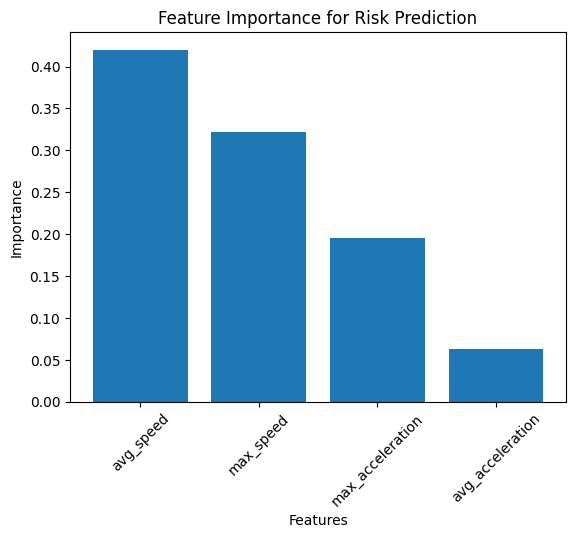

In [ ]:
# ============================================================
# STEP 54: FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GET FEATURE IMPORTANCE
# ------------------------------------------------------------
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print("============================================================")
print("STEP 54: FEATURE IMPORTANCE")
print("============================================================")

display(feature_importance_df)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
plt.figure()
plt.bar(feature_importance_df["feature"], feature_importance_df["importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance for Risk Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
# ============================================================
# STEP 55: CHECK AVAILABLE FEATURES BEFORE MODEL IMPROVEMENT
# ============================================================
# WHY:
# ------------------------------------------------------------
# Before adding brightness, contrast, YOLO, or anomaly_score
# into the model, we need to check whether these columns already
# exist in final_df.
#
# This prevents errors and helps us build the model properly.

print("============================================================")
print("STEP 55: AVAILABLE COLUMNS IN FINAL DATASET")
print("============================================================")

print("Total columns:", len(final_df.columns))

for col in final_df.columns:
    print(col)

print("\n============================================================")
print("SEARCHING FOR IMPORTANT FEATURE COLUMNS")
print("============================================================")

keywords = ["brightness", "contrast", "yolo", "object", "count", "anomaly", "score"]

for keyword in keywords:
    matching_cols = [col for col in final_df.columns if keyword.lower() in col.lower()]
    print(f"\nColumns matching '{keyword}':")
    print(matching_cols)

STEP 55: AVAILABLE COLUMNS IN FINAL DATASET
Total columns: 54
clip_id
country
month
hour_of_day
platform_class
radar_config
egomotion
egomotion.offline
obstacle.offline
camera_intrinsics
camera_intrinsics.offline
lidar_intrinsics.offline
sensor_extrinsics
sensor_extrinsics.offline
vehicle_dimensions
camera_cross_left_120fov
camera_cross_right_120fov
camera_front_tele_30fov
camera_front_wide_120fov
camera_rear_left_70fov
camera_rear_right_70fov
camera_rear_tele_30fov
lidar_top_360fov
radar_corner_front_left_srr_0
radar_corner_front_left_srr_3
radar_corner_front_right_srr_0
radar_corner_front_right_srr_3
radar_corner_rear_left_srr_0
radar_corner_rear_left_srr_3
radar_corner_rear_right_srr_0
radar_corner_rear_right_srr_3
radar_front_center_imaging_lrr_1
radar_front_center_mrr_2
radar_front_center_srr_0
radar_rear_left_mrr_2
radar_rear_left_srr_0
radar_rear_right_mrr_2
radar_rear_right_srr_0
radar_side_left_srr_0
radar_side_left_srr_3
radar_side_right_srr_0
radar_side_right_srr_3
anomaly_s

In [ ]:
# ============================================================
# STEP 56: SAVE OLD VISUAL PROOF-OF-CONCEPT RESULTS
# ============================================================
# WHY:
# ------------------------------------------------------------
# Earlier in the notebook, we tested brightness and contrast
# on a very small sample of frames.
#
# That work was useful as proof that the method works.
# However, it was too small for final dissertation modelling.
#
# Before rebuilding visual features properly, we save the old
# proof-of-concept results so nothing is lost.

print("============================================================")
print("STEP 56: SAVE OLD VISUAL FEATURE TEST RESULTS")
print("============================================================")

try:
    visual_stats_df.to_csv("step56_old_visual_stats_proof_of_concept.csv", index=False)

    print("Old visual_stats_df saved successfully.")
    print("Shape:", visual_stats_df.shape)

    print("\nFirst few rows:")
    display(visual_stats_df.head())

except NameError:
    print("visual_stats_df was not found in memory.")
    print("This means the runtime may have reset, or the earlier visual cell was not run.")
    print("No issue. We will rebuild visual features properly from the selected clips.")

STEP 56: SAVE OLD VISUAL FEATURE TEST RESULTS
Old visual_stats_df saved successfully.
Shape: (10, 4)

First few rows:


In [ ]:
# ============================================================
# STEP 57: PREPARE CLIP IDS FOR VISUAL FEATURE EXTRACTION
# ============================================================

import os

print("============================================================")
print("STEP 57: PREPARING CLIPS FOR VISUAL FEATURE EXTRACTION")
print("============================================================")

# ------------------------------------------------------------
# GET CLIP IDS FROM FINAL DATASET
# ------------------------------------------------------------
clip_ids = final_df["clip_id"].tolist()

print("Number of clips to process:", len(clip_ids))
print("\nFirst 5 clip IDs:")
print(clip_ids[:5])

# ------------------------------------------------------------
# CREATE FOLDER FOR NEW FRAME EXTRACTION
# ------------------------------------------------------------
os.makedirs("step57_frames", exist_ok=True)

print("\nFolder 'step57_frames' created.")

In [ ]:
# ============================================================
# STEP 58: EXTRACT MIDDLE FRAMES FOR FINAL DATASET CLIPS
# ============================================================
# WHY:
# ------------------------------------------------------------
# Earlier, we tested brightness, contrast, and YOLO on only
# 5 rare and 5 normal clips.
#
# Now we repeat the same idea properly for the current final_df.
# This will create visual features for the same clips that already
# have speed, acceleration, anomaly score, and risk label.
#
# We use:
# - front-wide camera
# - middle frame of each video
#
# This keeps the visual extraction consistent and manageable.

import os
import zipfile
import cv2
from huggingface_hub import hf_hub_download

# ------------------------------------------------------------
# BASIC SETTINGS
# ------------------------------------------------------------
dataset_name = "nvidia/PhysicalAI-Autonomous-Vehicles"
camera_name = "camera_front_wide_120fov"

output_folder = "step58_final_frames"
os.makedirs(output_folder, exist_ok=True)

# ------------------------------------------------------------
# FUNCTION TO EXTRACT ONE MIDDLE FRAME
# ------------------------------------------------------------
def extract_middle_frame_for_clip(row):
    clip_id = row["clip_id"]
    chunk_number = int(row["chunk"])

    chunk_str = f"{chunk_number:04d}"
    zip_filename = f"camera/{camera_name}/{camera_name}.chunk_{chunk_str}.zip"

    target_mp4_name = f"{clip_id}.{camera_name}.mp4"

    try:
        # Download the camera chunk ZIP from Hugging Face
        zip_local_path = hf_hub_download(
            repo_id=dataset_name,
            filename=zip_filename,
            repo_type="dataset"
        )

        # Find the correct MP4 inside the ZIP
        with zipfile.ZipFile(zip_local_path, "r") as zf:
            members = zf.namelist()
            matching = [m for m in members if target_mp4_name in m]

            if len(matching) == 0:
                return {
                    "clip_id": clip_id,
                    "frame_path": None,
                    "frame_extracted": False,
                    "error": "MP4 not found in ZIP"
                }

            target_member = matching[0]

            # Extract video temporarily
            temp_video_folder = "step58_temp_videos"
            os.makedirs(temp_video_folder, exist_ok=True)

            zf.extract(target_member, path=temp_video_folder)

        video_path = os.path.join(temp_video_folder, target_member)

        # Read video and extract middle frame
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            cap.release()
            return {
                "clip_id": clip_id,
                "frame_path": None,
                "frame_extracted": False,
                "error": "No frames found"
            }

        middle_frame_index = total_frames // 2
        cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_index)

        success, frame = cap.read()
        cap.release()

        if not success:
            return {
                "clip_id": clip_id,
                "frame_path": None,
                "frame_extracted": False,
                "error": "Middle frame could not be read"
            }

        frame_path = os.path.join(output_folder, f"{clip_id}_middle.jpg")
        cv2.imwrite(frame_path, frame)

        return {
            "clip_id": clip_id,
            "frame_path": frame_path,
            "frame_extracted": True,
            "error": None
        }

    except Exception as e:
        return {
            "clip_id": clip_id,
            "frame_path": None,
            "frame_extracted": False,
            "error": str(e)
        }

# ------------------------------------------------------------
# PROCESS ALL CLIPS IN final_df
# ------------------------------------------------------------
frame_results = []

for i, row in final_df.iterrows():
    result = extract_middle_frame_for_clip(row)
    frame_results.append(result)

    if i % 10 == 0:
        print(f"Processed {i} clips")

# ------------------------------------------------------------
# CREATE FRAME RESULT DATAFRAME
# ------------------------------------------------------------
frame_results_df = pd.DataFrame(frame_results)

print("============================================================")
print("STEP 58 COMPLETE: FRAME EXTRACTION FINISHED")
print("============================================================")
print("Shape:", frame_results_df.shape)

print("\nFrame extraction status:")
print(frame_results_df["frame_extracted"].value_counts())

display(frame_results_df.head())

camera/camera_front_wide_120fov/camera_f(…):   0%|          | 0.00/1.23G [00:00<?, ?B/s]

Processed 0 clips
Processed 10 clips
Processed 20 clips
Processed 30 clips
Processed 40 clips
Processed 50 clips
Processed 60 clips
STEP 58 COMPLETE: FRAME EXTRACTION FINISHED
Shape: (62, 4)

Frame extraction status:
frame_extracted
True    62
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 59: COMPUTE BRIGHTNESS AND CONTRAST FOR FINAL FRAMES
# ============================================================

import cv2
import numpy as np
import pandas as pd

print("============================================================")
print("STEP 59: COMPUTING VISUAL FEATURES")
print("============================================================")

# ------------------------------------------------------------
# FUNCTION TO COMPUTE BRIGHTNESS & CONTRAST
# ------------------------------------------------------------
def compute_visual_features(image_path):
    try:
        img = cv2.imread(image_path)

        if img is None:
            return None, None

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)
        contrast = np.std(gray)

        return brightness, contrast

    except:
        return None, None

# ------------------------------------------------------------
# APPLY TO ALL FRAMES
# ------------------------------------------------------------
visual_features = []

for i, row in frame_results_df.iterrows():
    clip_id = row["clip_id"]
    frame_path = row["frame_path"]

    brightness, contrast = compute_visual_features(frame_path)

    visual_features.append({
        "clip_id": clip_id,
        "brightness": brightness,
        "contrast": contrast
    })

    if i % 10 == 0:
        print(f"Processed {i} frames")

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
visual_features_df = pd.DataFrame(visual_features)

print("\n============================================================")
print("STEP 59 COMPLETE")
print("============================================================")

print("Shape:", visual_features_df.shape)
display(visual_features_df.head())

STEP 59: COMPUTING VISUAL FEATURES
Processed 0 frames
Processed 10 frames
Processed 20 frames
Processed 30 frames
Processed 40 frames
Processed 50 frames
Processed 60 frames

STEP 59 COMPLETE
Shape: (62, 3)


In [ ]:
# ============================================================
# STEP 60: MERGE VISUAL FEATURES INTO FINAL DATASET
# ============================================================

print("============================================================")
print("STEP 60: MERGING VISUAL FEATURES")
print("============================================================")

# ------------------------------------------------------------
# MERGE
# ------------------------------------------------------------
final_df_v2 = pd.merge(
    final_df,
    visual_features_df,
    on="clip_id",
    how="inner"
)

print("\nFinal dataset with visual features:")
print("Shape:", final_df_v2.shape)

display(final_df_v2.head())

STEP 60: MERGING VISUAL FEATURES

Final dataset with visual features:
Shape: (62, 56)


In [ ]:
# ============================================================
# STEP 61: IMPROVED MODEL WITH ALL FEATURES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("============================================================")
print("STEP 61: TRAINING IMPROVED MODELS")
print("============================================================")

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------
features_all = [
    "avg_speed",
    "max_speed",
    "avg_acceleration",
    "max_acceleration",
    "brightness",
    "contrast",
    "anomaly_score"
]

X = final_df_v2[features_all]
y = final_df_v2["risk"]

# ------------------------------------------------------------
# SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n================ RANDOM FOREST =================")
print(classification_report(y_test, rf_pred))

# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\n================ LOGISTIC REGRESSION =================")
print(classification_report(y_test, lr_pred))

STEP 61: TRAINING IMPROVED MODELS

================ RANDOM FOREST =================
              precision    recall  f1-score   support

        HIGH       1.00      0.89      0.94         9
         LOW       0.75      1.00      0.86         3
      MEDIUM       1.00      1.00      1.00         1

    accuracy                           0.92        13
   macro avg       0.92      0.96      0.93        13
weighted avg       0.94      0.92      0.93        13


================ LOGISTIC REGRESSION =================
              precision    recall  f1-score   support

        HIGH       1.00      0.44      0.62         9
         LOW       0.60      1.00      0.75         3
      MEDIUM       0.25      1.00      0.40         1

    accuracy                           0.62        13
   macro avg       0.62      0.81      0.59        13
weighted avg       0.85      0.62      0.63        13



In [ ]:
# ============================================================
# STEP 62: YOLO OBJECT DETECTION ON FINAL FRAMES
# ============================================================

from ultralytics import YOLO
import cv2
import pandas as pd

print("============================================================")
print("STEP 62: RUNNING YOLO ON FINAL FRAMES")
print("============================================================")

# ------------------------------------------------------------
# LOAD YOLO MODEL
# ------------------------------------------------------------
model = YOLO("yolov8n.pt")  # lightweight version

# ------------------------------------------------------------
# PROCESS ALL FRAMES
# ------------------------------------------------------------
yolo_results = []

for i, row in frame_results_df.iterrows():
    clip_id = row["clip_id"]
    frame_path = row["frame_path"]

    try:
        results = model(frame_path, verbose=False)

        # Count number of detected objects
        object_count = len(results[0].boxes)

        yolo_results.append({
            "clip_id": clip_id,
            "object_count": object_count
        })

    except Exception as e:
        yolo_results.append({
            "clip_id": clip_id,
            "object_count": None
        })

    if i % 10 == 0:
        print(f"Processed {i} frames")

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
yolo_df = pd.DataFrame(yolo_results)

print("\n============================================================")
print("STEP 62 COMPLETE")
print("============================================================")

print("Shape:", yolo_df.shape)
display(yolo_df.head())

STEP 62: RUNNING YOLO ON FINAL FRAMES
Processed 0 frames
Processed 10 frames
Processed 20 frames
Processed 30 frames
Processed 40 frames
Processed 50 frames
Processed 60 frames

STEP 62 COMPLETE
Shape: (62, 2)


In [ ]:
# ============================================================
# STEP 63: MERGE YOLO FEATURES
# ============================================================

print("============================================================")
print("STEP 63: MERGING YOLO FEATURES")
print("============================================================")

final_df_v3 = pd.merge(
    final_df_v2,
    yolo_df,
    on="clip_id",
    how="inner"
)

print("\nFinal dataset with YOLO:")
print("Shape:", final_df_v3.shape)

display(final_df_v3.head())

STEP 63: MERGING YOLO FEATURES

Final dataset with YOLO:
Shape: (62, 57)


In [ ]:
# ============================================================
# STEP 64: FINAL MODEL WITH ALL FEATURES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("============================================================")
print("STEP 64: FINAL MODEL TRAINING")
print("============================================================")

# ------------------------------------------------------------
# FEATURES (FINAL SET)
# ------------------------------------------------------------
features_final = [
    "avg_speed",
    "max_speed",
    "avg_acceleration",
    "max_acceleration",
    "brightness",
    "contrast",
    "anomaly_score",
    "object_count"
]

X = final_df_v3[features_final]
y = final_df_v3["risk"]

# ------------------------------------------------------------
# SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------
rf_model_final = RandomForestClassifier(random_state=42)
rf_model_final.fit(X_train, y_train)

rf_pred_final = rf_model_final.predict(X_test)

print("\n================ FINAL RANDOM FOREST =================")
print(classification_report(y_test, rf_pred_final))

# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------
lr_model_final = LogisticRegression(max_iter=1000)
lr_model_final.fit(X_train, y_train)

lr_pred_final = lr_model_final.predict(X_test)

print("\n================ FINAL LOGISTIC REGRESSION =================")
print(classification_report(y_test, lr_pred_final))

STEP 64: FINAL MODEL TRAINING

================ FINAL RANDOM FOREST =================
              precision    recall  f1-score   support

        HIGH       1.00      0.89      0.94         9
         LOW       0.75      1.00      0.86         3
      MEDIUM       1.00      1.00      1.00         1

    accuracy                           0.92        13
   macro avg       0.92      0.96      0.93        13
weighted avg       0.94      0.92      0.93        13


================ FINAL LOGISTIC REGRESSION =================
              precision    recall  f1-score   support

        HIGH       1.00      0.44      0.62         9
         LOW       0.60      1.00      0.75         3
      MEDIUM       0.25      1.00      0.40         1

    accuracy                           0.62        13
   macro avg       0.62      0.81      0.59        13
weighted avg       0.85      0.62      0.63        13



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


STEP 65: FINAL FEATURE IMPORTANCE


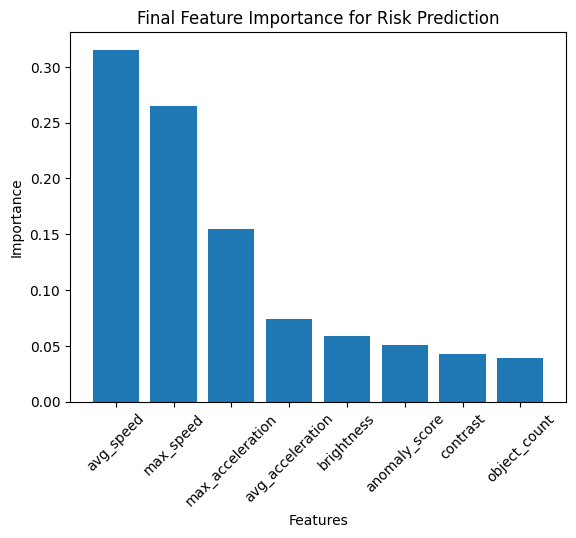

In [ ]:
# ============================================================
# STEP 65: FINAL FEATURE IMPORTANCE WITH ALL FEATURES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

importance_final = rf_model_final.feature_importances_

feature_importance_final_df = pd.DataFrame({
    "feature": features_final,
    "importance": importance_final
}).sort_values(by="importance", ascending=False)

print("============================================================")
print("STEP 65: FINAL FEATURE IMPORTANCE")
print("============================================================")

display(feature_importance_final_df)

plt.figure()
plt.bar(
    feature_importance_final_df["feature"],
    feature_importance_final_df["importance"]
)
plt.xticks(rotation=45)
plt.title("Final Feature Importance for Risk Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [ ]:
# ============================================================
# STEP 66: EXTRACT YOLO OBJECT CATEGORY COUNTS
# ============================================================
# WHY:
# ------------------------------------------------------------
# Earlier, we only counted total objects.
# That is too simple because different objects have different risk meanings.
#
# Example:
# - 5 cars may indicate traffic density
# - 1 pedestrian may indicate higher safety risk
# - traffic lights/signs may indicate complex road context
#
# In this step, we extract separate object categories using YOLO.

from ultralytics import YOLO
import pandas as pd

print("============================================================")
print("STEP 66: EXTRACTING YOLO OBJECT CATEGORY FEATURES")
print("============================================================")

# ------------------------------------------------------------
# LOAD YOLO MODEL
# ------------------------------------------------------------
yolo_model = YOLO("yolov8n.pt")

# ------------------------------------------------------------
# DEFINE OBJECT CLASSES WE CARE ABOUT
# ------------------------------------------------------------
# YOLO class names usually include:
# person, bicycle, car, motorcycle, bus, truck, traffic light, stop sign, etc.
important_classes = [
    "person",
    "car",
    "truck",
    "bus",
    "motorcycle",
    "bicycle",
    "traffic light",
    "stop sign"
]

# ------------------------------------------------------------
# PROCESS FRAMES
# ------------------------------------------------------------
category_results = []

for i, row in frame_results_df.iterrows():

    clip_id = row["clip_id"]
    frame_path = row["frame_path"]

    # Default counts start at zero
    counts = {
        "clip_id": clip_id,
        "person_count": 0,
        "car_count": 0,
        "truck_count": 0,
        "bus_count": 0,
        "motorcycle_count": 0,
        "bicycle_count": 0,
        "traffic_light_count": 0,
        "stop_sign_count": 0,
        "total_relevant_objects": 0
    }

    try:
        results = yolo_model(frame_path, verbose=False)

        boxes = results[0].boxes

        for box in boxes:
            class_id = int(box.cls[0])
            class_name = yolo_model.names[class_id]

            if class_name in important_classes:
                column_name = class_name.replace(" ", "_") + "_count"
                counts[column_name] += 1
                counts["total_relevant_objects"] += 1

    except Exception as e:
        print("Error processing:", clip_id, "|", e)

    category_results.append(counts)

    if i % 10 == 0:
        print(f"Processed {i} frames")

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
yolo_category_df = pd.DataFrame(category_results)

print("\n============================================================")
print("STEP 66 COMPLETE")
print("============================================================")
print("Shape:", yolo_category_df.shape)

display(yolo_category_df.head())

STEP 66: EXTRACTING YOLO OBJECT CATEGORY FEATURES
Processed 0 frames
Processed 10 frames
Processed 20 frames
Processed 30 frames
Processed 40 frames
Processed 50 frames
Processed 60 frames

STEP 66 COMPLETE
Shape: (62, 10)


In [ ]:
# ============================================================
# STEP 67: MERGE YOLO CATEGORY FEATURES
# ============================================================

print("============================================================")
print("STEP 67: MERGING OBJECT CATEGORY FEATURES")
print("============================================================")

final_df_v4 = pd.merge(
    final_df_v3,
    yolo_category_df,
    on="clip_id",
    how="inner"
)

print("\nFinal dataset shape:", final_df_v4.shape)
display(final_df_v4.head())

STEP 67: MERGING OBJECT CATEGORY FEATURES

Final dataset shape: (62, 66)


In [ ]:
# ============================================================
# STEP 68: ADD JERK FEATURES
# ============================================================

import numpy as np

print("============================================================")
print("STEP 68: ADDING JERK FEATURES")
print("============================================================")

# ------------------------------------------------------------
# NOTE:
# We approximate jerk using existing aggregated features
# since raw time-series is already compressed.
# ------------------------------------------------------------

# Approximation: variability between max and avg acceleration
final_df_v4["jerk_proxy"] = (
    final_df_v4["max_acceleration"] - final_df_v4["avg_acceleration"]
)

print("\nJerk feature added.")
display(final_df_v4[["avg_acceleration", "max_acceleration", "jerk_proxy"]].head())


STEP 68: ADDING JERK FEATURES

Jerk feature added.


In [ ]:
# ============================================================
# STEP 69: ADD CONTEXT FEATURES
# ============================================================

print("============================================================")
print("STEP 69: ADDING CONTEXT FEATURES")
print("============================================================")

# ------------------------------------------------------------
# DAY / NIGHT
# ------------------------------------------------------------
final_df_v4["is_night"] = final_df_v4["hour_of_day"].apply(
    lambda x: 1 if (x >= 20 or x <= 6) else 0
)

# ------------------------------------------------------------
# PEAK HOURS (rush traffic)
# ------------------------------------------------------------
final_df_v4["is_peak_hour"] = final_df_v4["hour_of_day"].apply(
    lambda x: 1 if (7 <= x <= 10 or 16 <= x <= 19) else 0
)

print("\nContext features added.")
display(final_df_v4[["hour_of_day", "is_night", "is_peak_hour"]].head())

STEP 69: ADDING CONTEXT FEATURES

Context features added.


In [ ]:
# ============================================================
# STEP 70: FINAL ADVANCED MODEL WITH BEHAVIOUR + VISION + CONTEXT
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

print("============================================================")
print("STEP 70: FINAL ADVANCED MODEL")
print("============================================================")

features_advanced = [
    # Behaviour
    "avg_speed",
    "max_speed",
    "avg_acceleration",
    "max_acceleration",
    "jerk_proxy",

    # Visual
    "brightness",
    "contrast",

    # Scenario mining
    "anomaly_score",

    # YOLO object categories
    "person_count",
    "car_count",
    "truck_count",
    "bus_count",
    "motorcycle_count",
    "bicycle_count",
    "traffic_light_count",
    "stop_sign_count",
    "total_relevant_objects",

    # Context
    "is_night",
    "is_peak_hour"
]

X = final_df_v4[features_advanced]
y = final_df_v4["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------
rf_advanced = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf_advanced.fit(X_train, y_train)
rf_pred_advanced = rf_advanced.predict(X_test)

print("\n================ ADVANCED RANDOM FOREST ================")
print(classification_report(y_test, rf_pred_advanced))

# ------------------------------------------------------------
# LOGISTIC REGRESSION WITH SCALING
# ------------------------------------------------------------
lr_advanced = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000))
])

lr_advanced.fit(X_train, y_train)
lr_pred_advanced = lr_advanced.predict(X_test)

print("\n================ ADVANCED LOGISTIC REGRESSION ================")
print(classification_report(y_test, lr_pred_advanced))

STEP 70: FINAL ADVANCED MODEL

================ ADVANCED RANDOM FOREST ================
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         9
         LOW       1.00      1.00      1.00         3
      MEDIUM       1.00      1.00      1.00         1

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13


================ ADVANCED LOGISTIC REGRESSION ================
              precision    recall  f1-score   support

        HIGH       1.00      0.33      0.50         9
         LOW       0.50      1.00      0.67         3
      MEDIUM       0.25      1.00      0.40         1

    accuracy                           0.54        13
   macro avg       0.58      0.78      0.52        13
weighted avg       0.83      0.54      0.53        13

